# Klassificering av ansiktsuttryck med deep learning

Detta projekt går ut på att bygga en modell med neurala nätverk som kan klassificera ansiktsutryck. 

Projektet inleds med en undersökning av datan och förberedelse av den. Då datasetet är stort så används initialt ett subset.

En basmodel byggs och olika experiment genomförs för att undersöka om den kan förbättras. En bredare och en djupare modellvariant undersöks också.

De modeller som får högst accuracy på valideringsdatan, är någorlunda stabil och snabb på subsetet väljs för att tränas på hela träningsdatan.

Därefter väljs den som presterar bäst av dem för att utvärdera med testdata och prediktioner.

In [1]:
# Grundläggande bibliotek
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split och utvärdering
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Förstå datan

Datasetet som används är FER-2013 och är redan uppdelat i ett träningsset och ett testset. Träningssetet används för att lära modellen klassificera ansiktsutryck medan testsetet endast används på slutet för att utvärdera modellen.

In [2]:
# Titta på datan

import os

# Räknar antal bilder totalt och per klass i tränings- och testdata

print("Antal klasser i train:", len(os.listdir("data/train")))
total_train_images = 0
for class_name in sorted(os.listdir("data/train")):
    count = len(os.listdir(f"data/train/{class_name}"))
    total_train_images += count
    print(f"{class_name}: {count} bilder")
print(f"\nTotalt antal bilder i train: {total_train_images}")

print("---------------------------------------------")

print(f"Antal klasser i test:", len(os.listdir("data/test")))
total_test_images = 0
for class_name in sorted(os.listdir("data/test")):
    count = len(os.listdir(f"data/test/{class_name}"))
    total_test_images += count
    print(f"{class_name}: {count} bilder")
print(f"\nTotalt antal bilder i test: {total_test_images}")

Antal klasser i train: 7
angry: 3995 bilder
disgust: 436 bilder
fear: 4097 bilder
happy: 7215 bilder
neutral: 4965 bilder
sad: 4830 bilder
surprise: 3171 bilder

Totalt antal bilder i train: 28709
---------------------------------------------
Antal klasser i test: 7
angry: 958 bilder
disgust: 111 bilder
fear: 1024 bilder
happy: 1774 bilder
neutral: 1233 bilder
sad: 1247 bilder
surprise: 831 bilder

Totalt antal bilder i test: 7178


### Kommentar:  
Träningsdatan består av 28709 bilder och tesdatan av 7178 bilder vilket är 20% av det totala antalet bilder 35887.  
Klassen disgust sticker ut med färre bilder 436, runt 10 procent av övriga. Störst är klassen happy med 7215 bilder som är dubbelt så stor som den nästa minsta klassen surprise med 3171 bilder.

## 2. Förbered datan

In [3]:
# Packar upp zip-filen

import zipfile

with zipfile.ZipFile("data/FER-2013.zip", "r") as zip_ref:
    zip_ref.extractall("data/")

### Läser in data  

Datan läses in med ImageDataGenerator och normaliseras genom att pixelvärdena skalas från 0-255 till 0-1. Med flow_from_directory skalas bilderna till 48x48 pixlar och en kanal för gråskala. Labels sätts till heltal (sparse). För att underlätta vidare arbete så konverteras datan till numpy arrays.

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "data/train"
test_dir = "data/test"

# Normaliserar pixelvärden från 0-255 till 0-1
#Gör att modellen tränas på värden i samma skala
datagen = ImageDataGenerator(rescale=1./255)

# Läser in bilder från mappstruktur, 48x48 gråskala, labels som heltal
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),   # Alla bilder skalas om till 48x48 pixlar
    color_mode="grayscale", # Bilderna är i gråskala, så vi har bara en kanal
    class_mode="sparse",    # Labels som heltal (inte one-hot encoded)
    batch_size=32,          # Laddar in 32 bilder åt gången för att spara minne
    shuffle=True            # Blandar bilderna så att modellen inte lär sig i en specifik ordning
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    class_mode="sparse",
    batch_size=32,
    shuffle=False           # Ingen shuffling så att bildindex är reproducerbara för utvärdering senare
)

# Konvertera till numpy-arrays
X_train_full = np.concatenate([train_generator[i][0] for i in range(len(train_generator))], axis=0)
y_train_full = np.concatenate([train_generator[i][1] for i in range(len(train_generator))], axis=0).astype(int)

X_test = np.concatenate([test_generator[i][0] for i in range(len(test_generator))], axis=0)
y_test = np.concatenate([test_generator[i][1] for i in range(len(test_generator))], axis=0).astype(int)

# Sätter klassnamn baserat på mappstruktur
class_names = list(train_generator.class_indices.keys())

# Utskrift för kontroll av datan, labels och klassnamn
print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print(f"\nLabels på klasserna:")
for i, name in enumerate(class_names):
    print(i, name)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
X_train_full: (28709, 48, 48, 1)
y_train_full: (28709,)
X_test: (7178, 48, 48, 1)
y_test: (7178,)

Labels på klasserna:
0 angry
1 disgust
2 fear
3 happy
4 neutral
5 sad
6 surprise


### Exempelbilder

För att förstå datan bättre skrivs ett slumpmässigt antal bilder med klassnamn ut.

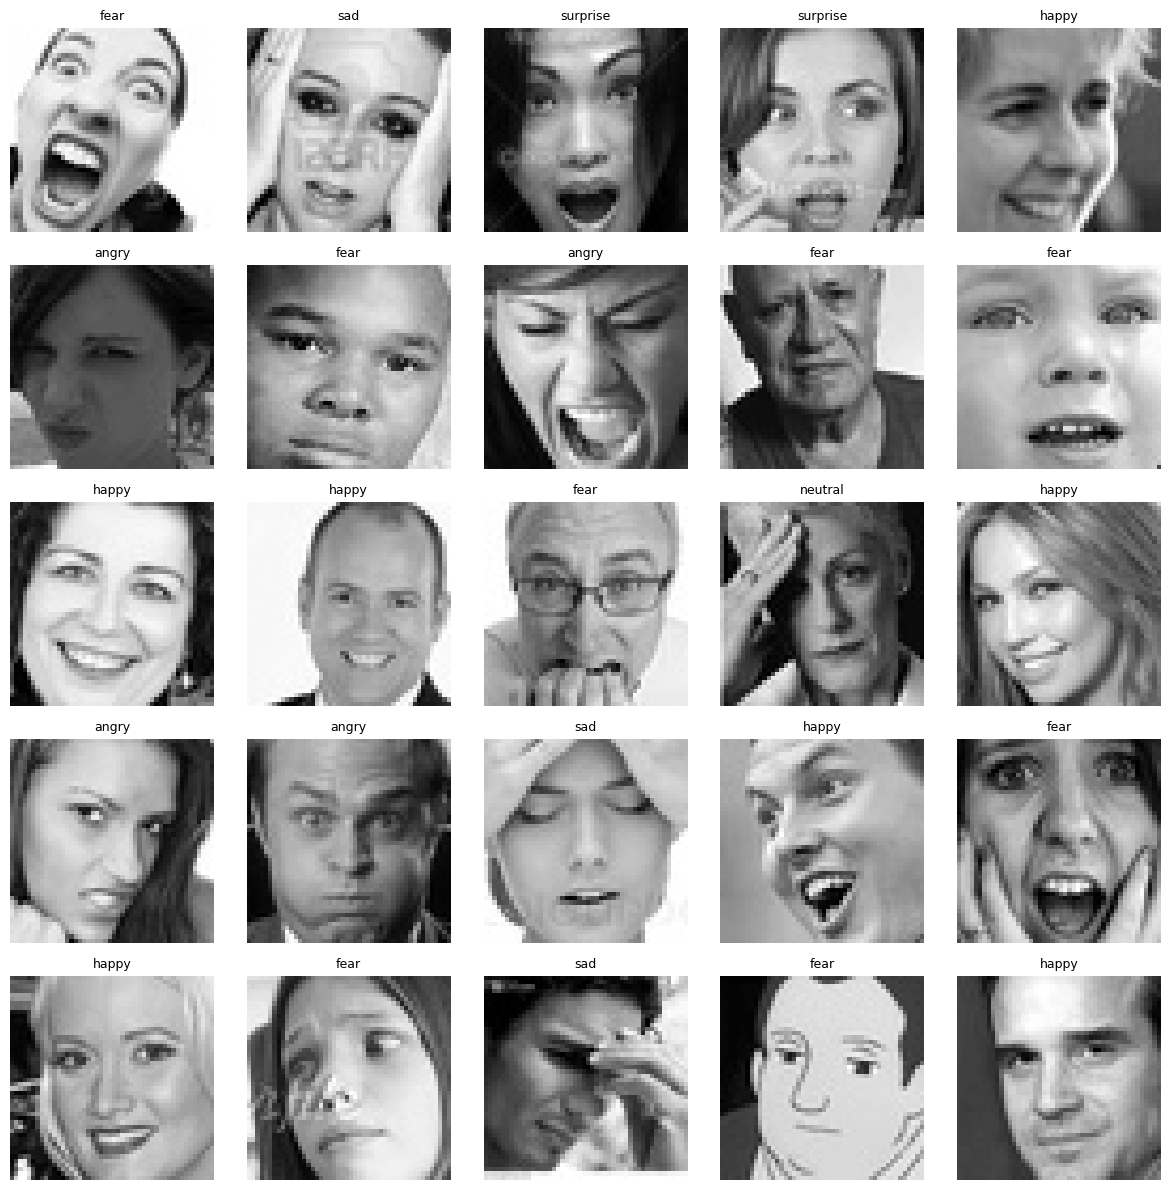

In [5]:
# Skriver ut 25 slumpmässiga bilder från träningsdata med deras klassnamn

n_images = 25
rng = np.random.default_rng(seed=42)
indices = rng.choice(len(X_train_full), size=n_images, replace=False)
plt.figure(figsize=(12, 12))

for i in range(n_images):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_full[indices[i]].squeeze(), cmap="gray")
    plt.title(class_names[y_train_full[indices[i]]], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Kommentar

Av de 25 slumpmässigt utvalda bilderna syns ingen disgust, vilket speglar klassens underrepresentation i datasetet. Det förekommer tecknade bilder, bilder med text över ansiktet och händer framför ansiktet, vilket kan vara en utmaning för modellen.

(Vissa av bilderna skulle jag ha tolkat som andra ansiktsuttryck vilket indikerar att denna typ av klassificering är antingen subjektiv eller att en del bilder är felklassificerade, eller båda.)

### Ta bort klassen disgust

Då klassen disgust innehåller betydligt färre bilder än övriga klasser så kommer klassen tas bort just nu för att få en mer robust modell. Om mer data 
samlas in i framtiden kan modellen tränas om med klassen inkluderad. 

In [6]:
# Ta bort disgust (klass 1) i träningsdata
mask = y_train_full != 1
X_filtered = X_train_full[mask]
y_filtered = y_train_full[mask]

# Ta bort disgust från testdata
mask_test = y_test != 1
X_test_filtered = X_test[mask_test]
y_test_filtered = y_test[mask_test]

# Mappa om labels till 0-5
unique_labels = np.unique(y_filtered)
label_map = {old: new for new, old in enumerate(unique_labels)}
y_filtered = np.array([label_map[y] for y in y_filtered])
y_test_filtered = np.array([label_map[y] for y in y_test_filtered])

# Uppdatera klassnamn utan disgust
class_names_filtered = [name for name in class_names if name != "disgust"]

### Skapa subset

Träningssetet innehåller 28709 bilder vilket kan ta lång tid att träna på. Experimenten kommer därför utföras på ett balanserat subset där alla klasser får lika stor storlek, vilket ger modellen lika goda förutsättningar att lära sig känna igen varje klass. När en bra modellkonfiguration hittats och även bredare och djupare modellvarianter testas kan träning ske på hela träningsdatan.

In [7]:
# Skapar ett balanserat subset med 500 bilder per klass
samples_per_class=500
rng = np.random.default_rng(42)
selected_indices = []

for class_id in np.unique(y_filtered):
    class_indices = np.where(y_filtered == class_id)[0]   
    chosen_indices = rng.choice(class_indices, size=samples_per_class, replace=False)
    selected_indices.extend(chosen_indices)

selected_indices = np.array(selected_indices)
rng.shuffle(selected_indices)

X_subset = X_filtered[selected_indices]
y_subset = y_filtered[selected_indices]

# Utskrift för kontroll av shapes och klassfördelning i det nya subsetet
print("X_subset:", X_subset.shape)
print("y_subset:", y_subset.shape)
print("\nLabels på klasserna efter borttagning av disgust och subset:")
unique, counts = np.unique(y_subset, return_counts=True)
for label, count in zip(unique, counts):
    print(f"{label} {class_names_filtered[label]}: {count} bilder")

X_subset: (3000, 48, 48, 1)
y_subset: (3000,)

Labels på klasserna efter borttagning av disgust och subset:
0 angry: 500 bilder
1 fear: 500 bilder
2 happy: 500 bilder
3 neutral: 500 bilder
4 sad: 500 bilder
5 surprise: 500 bilder


### Skapa valideringsset

Ett valideringsdataset skapas av 20% av träningsdatan för att kunna utvärdera hur modellen presterar på data den inte tränats på. Under träningen 
används valideringsdatan för att upptäcka om modellen lär sig träningsdatan för bra och överanpassar.

Eftersom subsetet redan är balanserat är stratifiering inte nödvändigt men används ändå som en säkerhetsåtgärd.

In [8]:
# Skapa validationsset från det nya subsetet (20% av datan)
X_train, X_val, y_train, y_val = train_test_split(
    X_subset,
    y_subset,
    test_size=0.20,
    random_state=42,
    stratify=y_subset
)

# Utskrift för kontroll av shapes i train/val-split
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (2400, 48, 48, 1)
X_val: (600, 48, 48, 1)
y_train: (2400,)
y_val: (600,)


## 3 och 4. Bygg en modell, träna modellen

### Funktion för att bygga och compilera modeller

Modellen är ett CNN (Convolutional Neural Network) med två eller en variant med tre Conv2D-lager som extraherar visuella mönster från bilderna, följt av MaxPooling-lager som reducerar bildernas storlek. Därefter plattas datan ut med ett Flatten-lager och skickas vidare till ett fully connected lager (Dense) som lär sig kombinera mönstren för klassificering. Sista lagret har 6 noder med softmax-aktivering, ett per känslouttryck, som ger sannolikheten för varje klass. Dropout och L2-regularisering kan läggas till för att motverka överanpassning.

Grundinställningar: 32 och 64 filter i de två första Conv2D-lagren, kernelstorlek 3×3, 128 noder i fully connected lagret och learning rate 0.001 med Adam som optimerare. Dessa värden justeras i de följande experimenten.

In [9]:
def build_model(
        num_filters_1=32,
        num_filters_2=64,
        num_filters_3=None,
        kernel_size=(3, 3),
        dense_units=128,
        learning_rate=0.001,
        dropout_rate=0.0,
        l2_strength=0.0
):
    """
    Bygger och kompilerar en CNN med två eller tre Conv2D-lager följt av ett fully connected lager (dense).
    Stöder dropout och L2-regularisering som hyperparametrar.

    Returnerar: kompilerad Keras-modell
    """
    tf.keras.utils.set_random_seed(42)
    
    kernels_regularizer = (
        regularizers.l2(l2_strength)
        if l2_strength > 0
        else None
    )

    model = keras.Sequential([
        layers.Input(shape=(48, 48, 1)),

        layers.Conv2D(num_filters_1, kernel_size=kernel_size, activation="relu",
                      padding="same", kernel_regularizer=kernels_regularizer),

        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(num_filters_2, kernel_size=kernel_size, activation="relu",
                      padding="same", kernel_regularizer=kernels_regularizer),
                      
        layers.MaxPooling2D(pool_size=(2, 2)),
    ])

    # Valfritt tredje Conv2D-lager
    if num_filters_3:
        model.add(layers.Conv2D(num_filters_3, kernel_size=kernel_size, activation="relu",
                                padding="same", kernel_regularizer=kernels_regularizer))
        
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(dense_units, activation="relu",
                            kernel_regularizer=kernels_regularizer))
        
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(6, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

### Funktion för att skapa träningskurvor

Träningskurvorna visar hur modellens loss och accuracy utvecklas över epoker för både tränings- och valideringsdata. Kurvorna används för att bedöma om 
modellen lär sig och om det finns tecken på överanpassning.

In [10]:
def plot_history(history, title="Träningskurvor"):

    """
    Plottar tränings- och valideringsförlust samt accuracy över epoker.
    """

    # Konverterar Keras History-objekt till DataFrame för enklare plottning    
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(12, 4))

    # Plottar loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Traning loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    # Plottar accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Traning accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### Funktion för att köra experiment och träna modeller

Experimenten körs med funktionen run_experiment som bygger och tränar en modell med angivna hyperparametrar. Resultaten sparas i en lista för att enkelt kunna jämföras mellan experiment. Alla mått hämtas från den epok som gav bäst valideringsnoggrannhet, vilket inte alltid behöver vara den sista.

In [11]:
def run_experiment(
        name,
        epochs=15,
        learning_rate=0.001,
        batch_size=64,
        num_filters_1=32,
        num_filters_2=64,
        num_filters_3=None,
        kernel_size=(3, 3),
        dense_units=128,
        dropout_rate=0.0,
        l2_strength=0.0,
        callbacks=None,
        verbose=0
):
    
    """
    Bygger, tränar och utvärderar en modell med angivna hyperparametrar.
    Returnerar: modell, history och dict med resultatmått.
    """

    model = build_model(
        num_filters_1=num_filters_1,
        num_filters_2=num_filters_2,
        num_filters_3=num_filters_3,
        kernel_size=kernel_size,
        dense_units=dense_units,
        learning_rate=learning_rate,
        dropout_rate=dropout_rate,
        l2_strength=l2_strength
    )

    print(f"\nExperiment: {name}")
    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    training_time = time.time() - start_time

    # Hämtar resultat från bästa epok baserat på val_accuracy
    best_index = np.argmax(history.history["val_accuracy"])

    train_acc  = history.history["accuracy"][best_index]
    train_loss = history.history["loss"][best_index]
    val_acc  = history.history["val_accuracy"][best_index]
    val_loss = history.history["val_loss"][best_index]


    print(f"Antal epoker: {len(history.history['loss'])}")
    print(f"Training accuracy: {train_acc:.4f}")
    print(f"Training loss: {train_loss:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Validation loss: {val_loss:.4f}")
    print(f"Träningstid: {training_time:.2f} sekunder")

    plot_history(history, title=name)

    return model, history, {
        "name": name,
        "train_accuracy": train_acc,
        "train_loss": train_loss,
        "val_accuracy": val_acc,
        "val_loss": val_loss,
        # "epochs_trained": len(history.history["loss"]),
        "best_epoch": best_index + 1,
        "training_time": training_time
    }

### Experiment

Experimenten utgår från en basmodell och förändringar görs iterativt utifrån resultaten.


Experiment: Basmodell
Antal epoker: 15
Training accuracy: 0.7638
Training loss: 0.6992
Validation accuracy: 0.3683
Validation loss: 2.0156
Träningstid: 20.12 sekunder


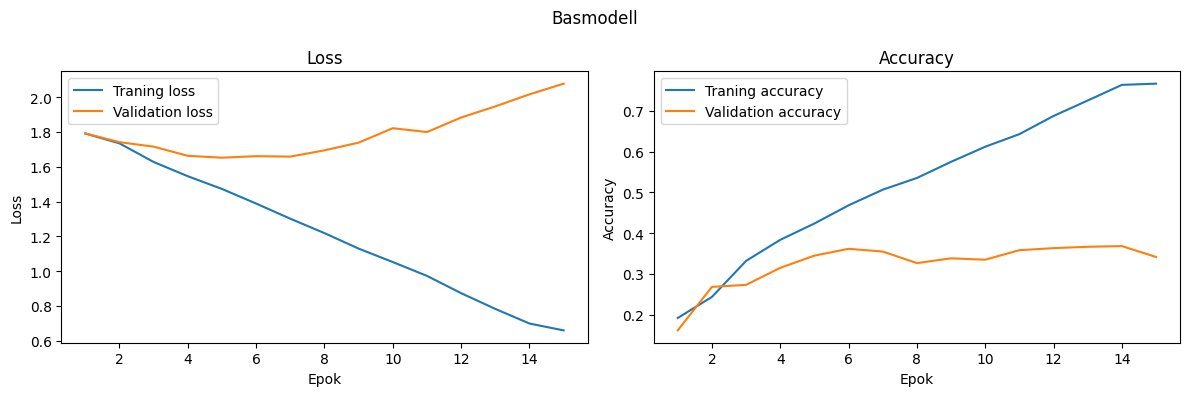

     name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
Basmodell         0.76375    0.699207      0.368333  2.015561          14      20.121974


In [12]:
# Basmodell

results = []

_, h_bas, r_bas = run_experiment("Basmodell")

results.append(r_bas)
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

Basmodellen börjar överanpassa efter cirka 6 epoker, accuracy på träningsdatan fortsätter öka medan accuracy på valideringsdatan planar ut. Efter 15 epoker når accuracy på träningsdatan 0,70 men på valideringsdatan bara 0,37. 
 
Ett nästa steg är att prova olika dropout-nivåer där en del av neuronerna stängs av slumpmässigt under träning för att motverka överanpassningen.


Experiment: Dropout 0.2
Antal epoker: 15
Training accuracy: 0.7979
Training loss: 0.6118
Validation accuracy: 0.3850
Validation loss: 1.8940
Träningstid: 20.31 sekunder


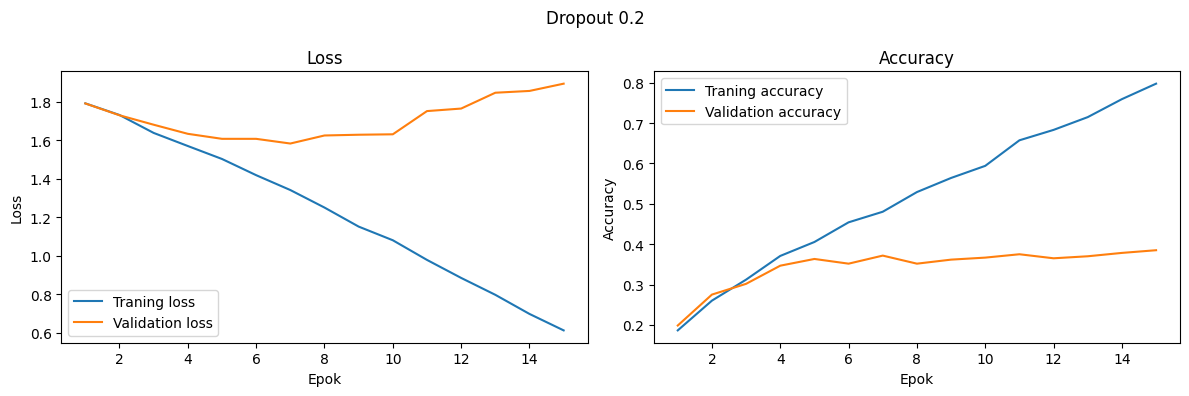


Experiment: Dropout 0.4
Antal epoker: 15
Training accuracy: 0.6558
Training loss: 0.9342
Validation accuracy: 0.3783
Validation loss: 1.7314
Träningstid: 21.27 sekunder


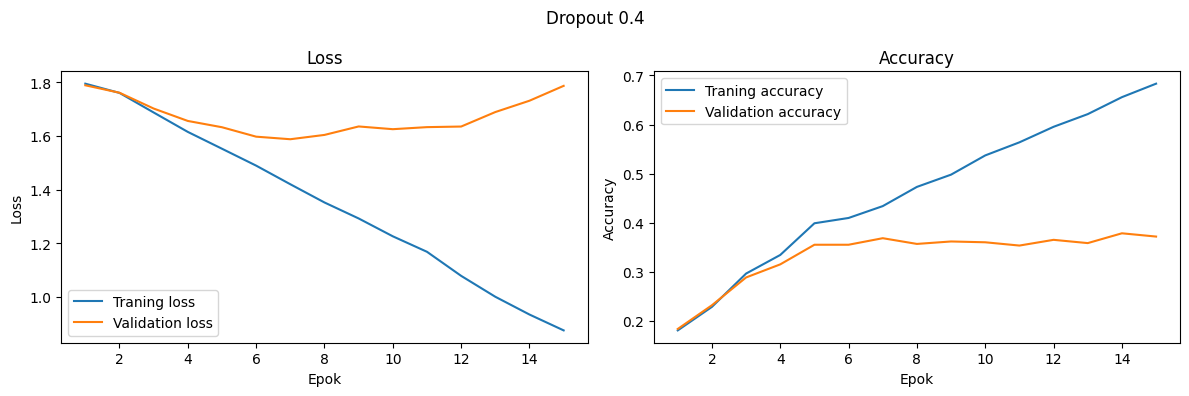


Experiment: Dropout 0.5
Antal epoker: 15
Training accuracy: 0.5883
Training loss: 1.0892
Validation accuracy: 0.3900
Validation loss: 1.6319
Träningstid: 20.84 sekunder


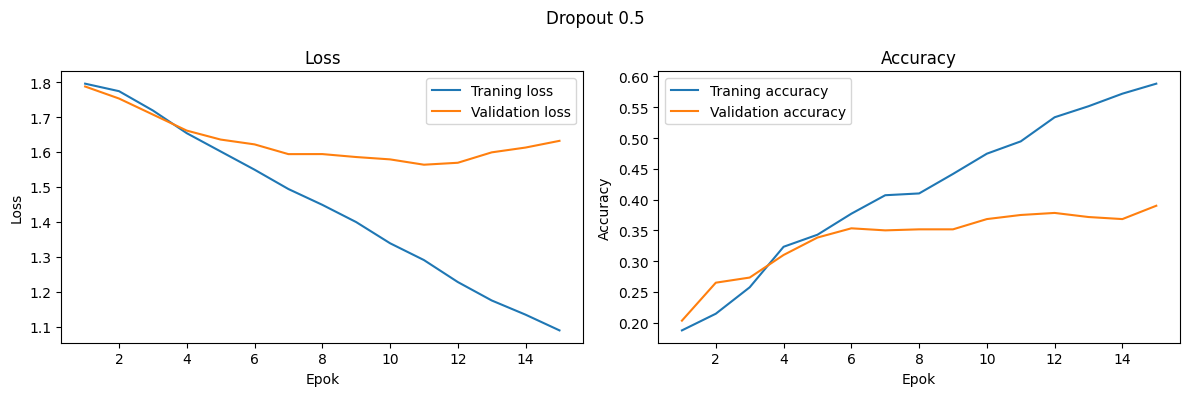

       name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
  Basmodell        0.763750    0.699207      0.368333  2.015561          14      20.121974
Dropout 0.2        0.797917    0.611834      0.385000  1.893981          15      20.308429
Dropout 0.4        0.655833    0.934150      0.378333  1.731448          14      21.269195
Dropout 0.5        0.588333    1.089161      0.390000  1.631879          15      20.843831


In [13]:
# Experiment med olika dropout

_, h_drop1, r_drop1 = run_experiment("Dropout 0.2", dropout_rate=0.2)
_, h_drop2, r_drop2 = run_experiment("Dropout 0.4", dropout_rate=0.4)
_, h_drop3, r_drop3 = run_experiment("Dropout 0.5", dropout_rate=0.5)

results.extend([r_drop1, r_drop2, r_drop3])
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

Dropout minskade gapet mellan accuracy på träningsdatan och valideringsdatan, dvs överanpassningen minskade. Accuracy på valideringsdatan blev bättre än för basbodellen och bäst med dropout 0,5. Kurvorna visar att träning och validering följer varandra bättre med dropout, dvs överanpassningen minskar.

I nästa experiment testas olika l2-styrkor för att reducera överanpassningen. L2 straffar modellen om den har för stora vikter och tvingar den generalisera bättre.


Experiment: L2 0.01
Antal epoker: 15
Training accuracy: 0.3462
Training loss: 1.6625
Validation accuracy: 0.3017
Validation loss: 1.7434
Träningstid: 22.79 sekunder


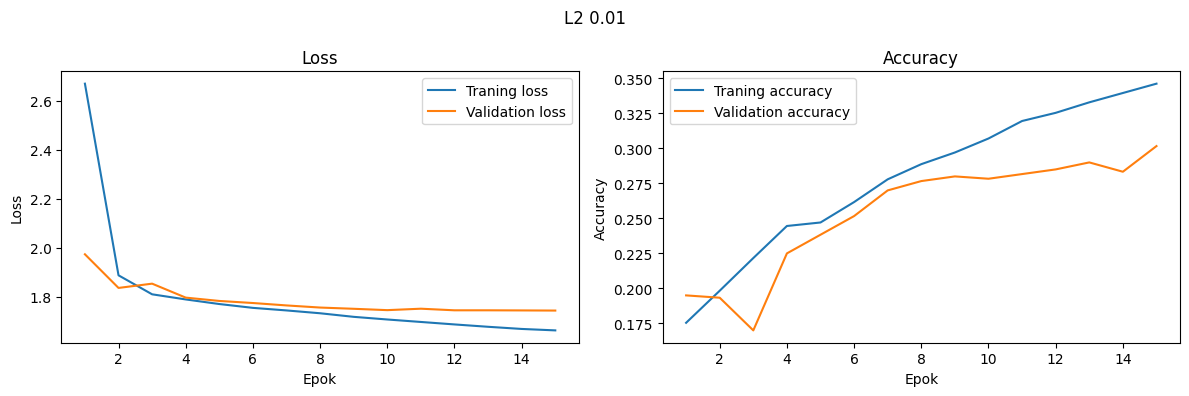


Experiment: L2 0.001
Antal epoker: 15
Training accuracy: 0.5063
Training loss: 1.3678
Validation accuracy: 0.3617
Validation loss: 1.7192
Träningstid: 22.83 sekunder


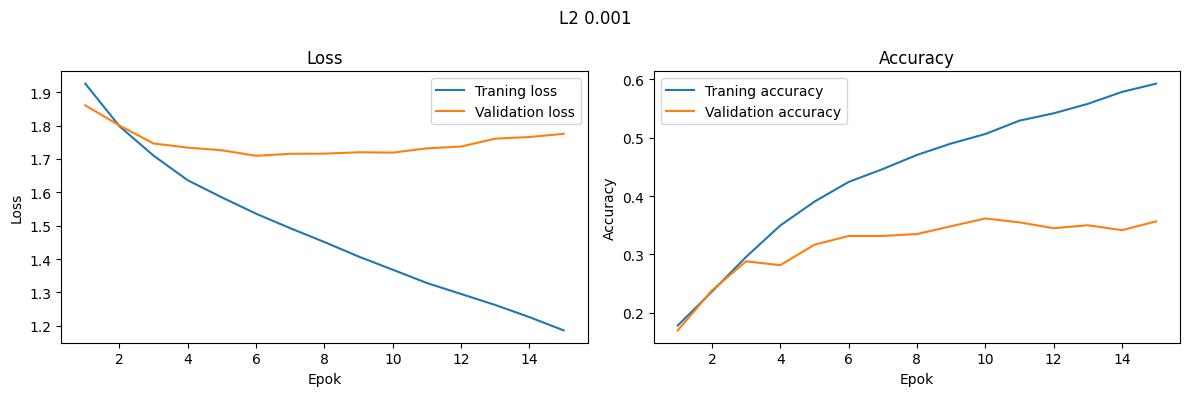


Experiment: L2 0.0001
Antal epoker: 15
Training accuracy: 0.7175
Training loss: 0.8504
Validation accuracy: 0.3767
Validation loss: 1.9558
Träningstid: 22.67 sekunder


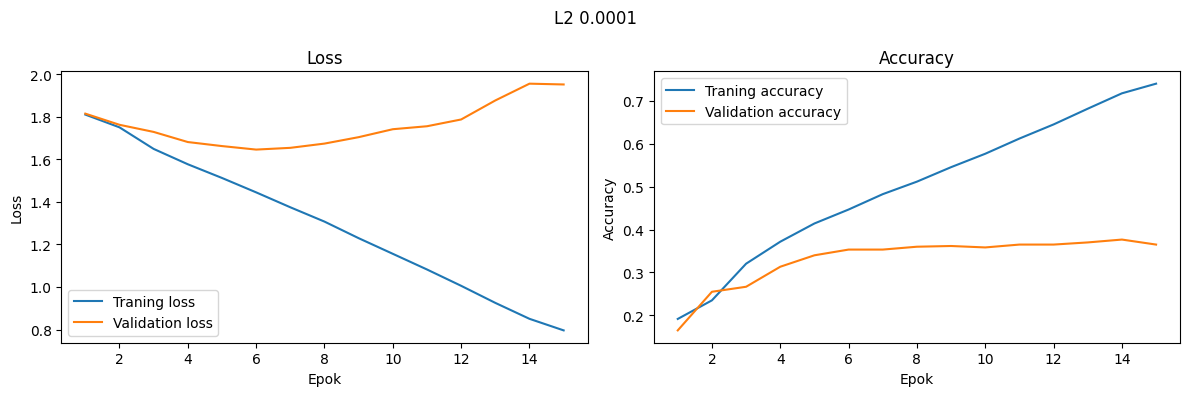

       name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
  Basmodell        0.763750    0.699207      0.368333  2.015561          14      20.121974
Dropout 0.2        0.797917    0.611834      0.385000  1.893981          15      20.308429
Dropout 0.4        0.655833    0.934150      0.378333  1.731448          14      21.269195
Dropout 0.5        0.588333    1.089161      0.390000  1.631879          15      20.843831
    L2 0.01        0.346250    1.662501      0.301667  1.743431          15      22.789530
   L2 0.001        0.506250    1.367846      0.361667  1.719191          10      22.834726
  L2 0.0001        0.717500    0.850400      0.376667  1.955794          14      22.673230


In [14]:
# Experiment med olika L2-styrkor

_, h_l2_1, r_l2_1 = run_experiment("L2 0.01", l2_strength=0.01)
_, h_l2_2, r_l2_2 = run_experiment("L2 0.001", l2_strength=0.001)
_, h_l2_3, r_l2_3 = run_experiment("L2 0.0001", l2_strength=0.0001)

results.extend([r_l2_1, r_l2_2, r_l2_3])
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

L2-regularisering gav ingen förbättring utan basmodellen med dropout 0,5 har forfarande högst accuracy på valideringsdatan. L2 0,01 var för stark och hämmade inlärningen kraftigt och uppnådde bara 30% accuracy på valideringsdatan medan L2 0,001 och 0,0001 gav liknande resultat som basmodellen. 

Att testa early stopping bedöms inte meningsfullt då överanpassning sker inom 6-8 epoker. Nästa experiment görs med olika learning rates.


Experiment: LR 0.0001
Antal epoker: 15
Training accuracy: 0.4154
Training loss: 1.5135
Validation accuracy: 0.3583
Validation loss: 1.6267
Träningstid: 20.56 sekunder


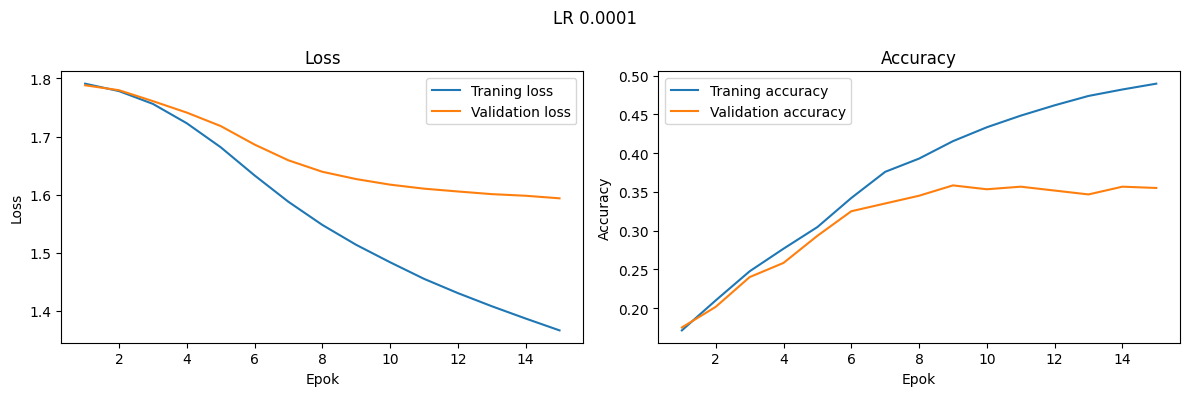


Experiment: LR 0.0005
Antal epoker: 15
Training accuracy: 0.5667
Training loss: 1.1709
Validation accuracy: 0.3683
Validation loss: 1.6306
Träningstid: 21.92 sekunder


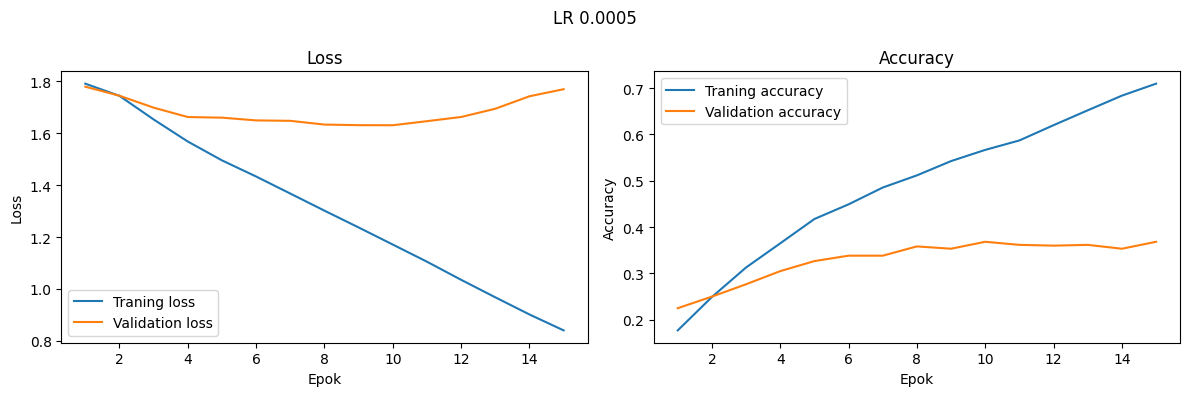


Experiment: LR 0.01
Antal epoker: 15
Training accuracy: 0.5167
Training loss: 1.2327
Validation accuracy: 0.3367
Validation loss: 2.3094
Träningstid: 23.31 sekunder


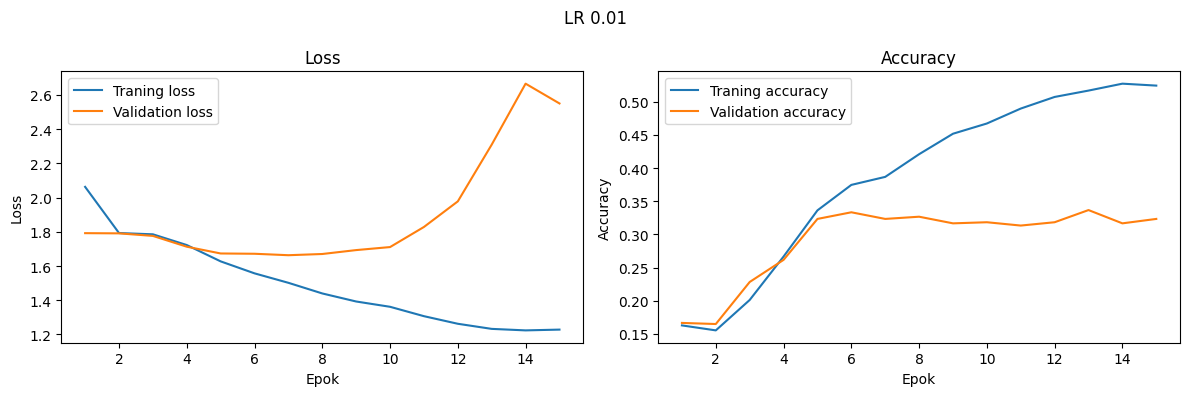

       name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
  Basmodell        0.763750    0.699207      0.368333  2.015561          14      20.121974
Dropout 0.2        0.797917    0.611834      0.385000  1.893981          15      20.308429
Dropout 0.4        0.655833    0.934150      0.378333  1.731448          14      21.269195
Dropout 0.5        0.588333    1.089161      0.390000  1.631879          15      20.843831
    L2 0.01        0.346250    1.662501      0.301667  1.743431          15      22.789530
   L2 0.001        0.506250    1.367846      0.361667  1.719191          10      22.834726
  L2 0.0001        0.717500    0.850400      0.376667  1.955794          14      22.673230
  LR 0.0001        0.415417    1.513549      0.358333  1.626718           9      20.556034
  LR 0.0005        0.566667    1.170923      0.368333  1.630627          10      21.919204
    LR 0.01        0.516667    1.232659      0.336667  2.309440          13      23.314434

In [15]:
# Experiment med olika learning rates

_, h_lr1, r_lr1 = run_experiment("LR 0.0001", learning_rate=0.0001)
_, h_lr2, r_lr2 = run_experiment("LR 0.0005", learning_rate=0.0005)
_, h_lr3, r_lr3 = run_experiment("LR 0.01", learning_rate=0.01)

results.extend([r_lr1, r_lr2, r_lr3])
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

De testade learning rates gav ingen förbättring utan basmodellen med dropout 0,5 har forfarande högst accuracy på valideringsdatan. LR 0,01 blev instabil med ojämna kurvor. 

I nästa experiment testas en bredare modell för att se om den kan bli bättre på att lära sig de komplexa mönster som ansiktsuttryck är. Antalet filter i Conv2D-lagren dubblas till 64 och 128, och även fully connected lagret dubbleras till 256 noder.  
Fler filter gör att modellen kan detektera fler olika mönster på samma nivå medan fler noder kan lagra fler kombinationer av mönster. 
En risk med en bredare model på en liten datamängd är att den överanpassar mer.


Experiment: Bredare modell
Antal epoker: 15
Training accuracy: 0.7042
Training loss: 0.8347
Validation accuracy: 0.3900
Validation loss: 1.8962
Träningstid: 62.35 sekunder


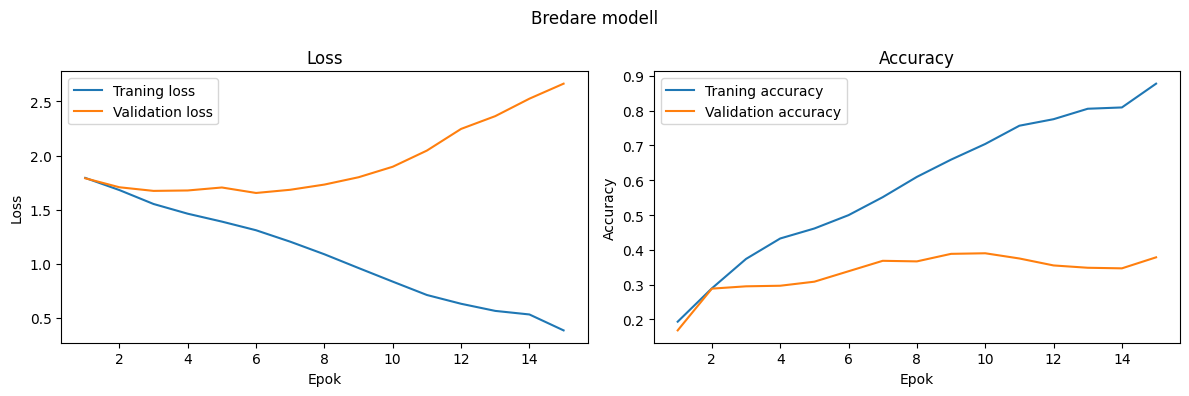

          name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
     Basmodell        0.763750    0.699207      0.368333  2.015561          14      20.121974
   Dropout 0.2        0.797917    0.611834      0.385000  1.893981          15      20.308429
   Dropout 0.4        0.655833    0.934150      0.378333  1.731448          14      21.269195
   Dropout 0.5        0.588333    1.089161      0.390000  1.631879          15      20.843831
       L2 0.01        0.346250    1.662501      0.301667  1.743431          15      22.789530
      L2 0.001        0.506250    1.367846      0.361667  1.719191          10      22.834726
     L2 0.0001        0.717500    0.850400      0.376667  1.955794          14      22.673230
     LR 0.0001        0.415417    1.513549      0.358333  1.626718           9      20.556034
     LR 0.0005        0.566667    1.170923      0.368333  1.630627          10      21.919204
       LR 0.01        0.516667    1.232659      0.336667  2.

In [16]:
# Experiment med bredare modell

_, h_broad, r_broad = run_experiment(
    "Bredare modell",
    num_filters_1=64,
    num_filters_2=128,
    dense_units=256,
)

results.append(r_broad)
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

Den bredare modellen får en lika hög accuracy på valideringsdatan som basmodellen men har en något högre loss. Den tar också nästa tre gånger så lång tid att träna.

I nästa experiment testas en djupare modell där ett tredje Conv2D lager med 128 filter läggs till. Varje Conv2D-lager bygger på det föregående. Tidiga lager hittar enkla mönster (kanter, linjer), senare lager kombinerar dessa till mer abstrakta mönster (ögon, munnar).


Experiment: Djupare modell
Antal epoker: 15
Training accuracy: 0.6862
Training loss: 0.8525
Validation accuracy: 0.3900
Validation loss: 1.8504
Träningstid: 29.61 sekunder


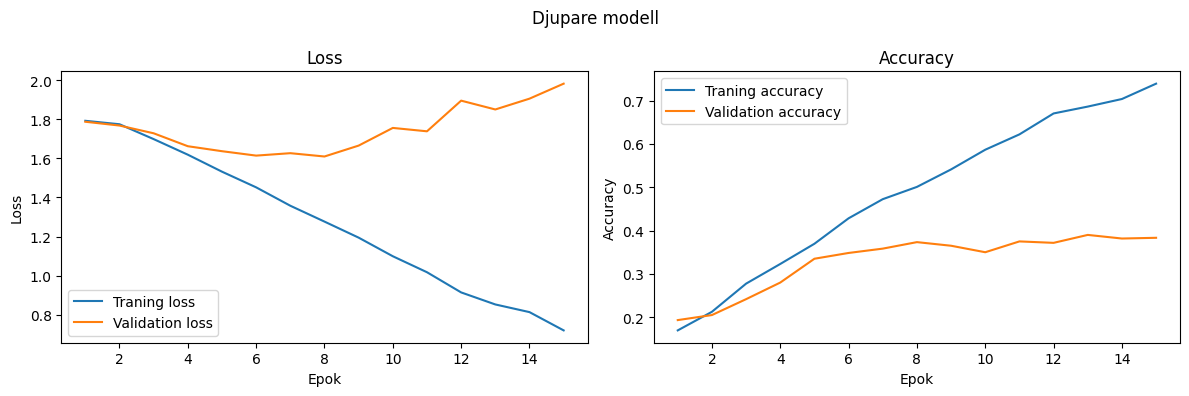

          name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
     Basmodell        0.763750    0.699207      0.368333  2.015561          14      20.121974
   Dropout 0.2        0.797917    0.611834      0.385000  1.893981          15      20.308429
   Dropout 0.4        0.655833    0.934150      0.378333  1.731448          14      21.269195
   Dropout 0.5        0.588333    1.089161      0.390000  1.631879          15      20.843831
       L2 0.01        0.346250    1.662501      0.301667  1.743431          15      22.789530
      L2 0.001        0.506250    1.367846      0.361667  1.719191          10      22.834726
     L2 0.0001        0.717500    0.850400      0.376667  1.955794          14      22.673230
     LR 0.0001        0.415417    1.513549      0.358333  1.626718           9      20.556034
     LR 0.0005        0.566667    1.170923      0.368333  1.630627          10      21.919204
       LR 0.01        0.516667    1.232659      0.336667  2.

In [17]:
# Experiment med djupare modell
model_deep, h_deep, r_deep = run_experiment(
    "Djupare modell",
    num_filters_3=128
)

results.append(r_deep)
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

Den djupare modellen får ett likande resultat på accuracy på valideringsdatan och på loss som den bredare modellen men träningstiden är kortare och ligger lika som basmodellen.

Nästa steg är att testa den bredare modellen och den djupare modellen, båda med dropout 0,5.


Experiment: Bredare modellen + dropout 0,5
Antal epoker: 15
Training accuracy: 0.7088
Training loss: 0.7690
Validation accuracy: 0.3883
Validation loss: 1.8341
Träningstid: 61.43 sekunder


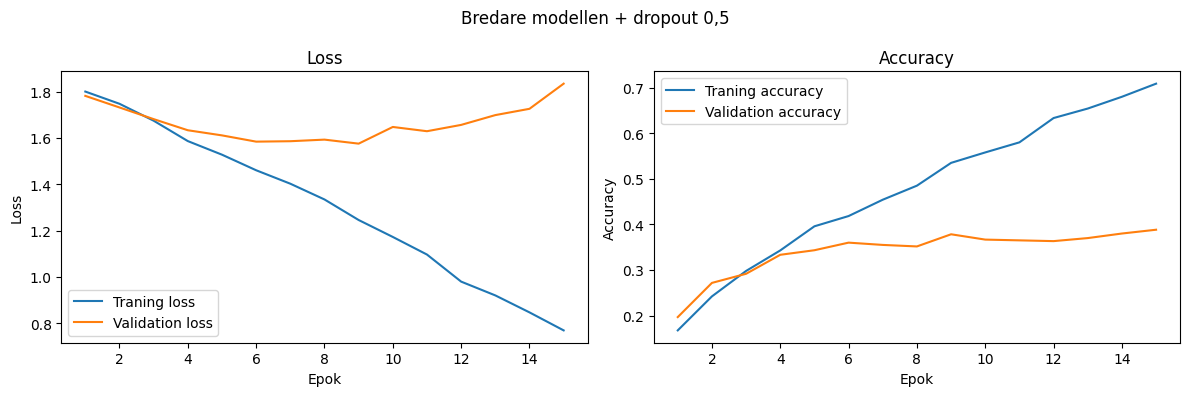

                          name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
                     Basmodell        0.763750    0.699207      0.368333  2.015561          14      20.121974
                   Dropout 0.2        0.797917    0.611834      0.385000  1.893981          15      20.308429
                   Dropout 0.4        0.655833    0.934150      0.378333  1.731448          14      21.269195
                   Dropout 0.5        0.588333    1.089161      0.390000  1.631879          15      20.843831
                       L2 0.01        0.346250    1.662501      0.301667  1.743431          15      22.789530
                      L2 0.001        0.506250    1.367846      0.361667  1.719191          10      22.834726
                     L2 0.0001        0.717500    0.850400      0.376667  1.955794          14      22.673230
                     LR 0.0001        0.415417    1.513549      0.358333  1.626718           9      20.556034
          

In [18]:
# Experiment med bredare modell och dropout 0,5

_, h_broad_dropout, r_broad_dropout = run_experiment(
    "Bredare modellen + dropout 0,5",
    num_filters_1=64,
    num_filters_2=128,
    dense_units=256,
    dropout_rate=0.5
)

results.append(r_broad_dropout)
print(pd.DataFrame(results).to_string(index=False))


Experiment: Djupare modellen + dropout 0,5
Antal epoker: 15
Training accuracy: 0.5492
Training loss: 1.1582
Validation accuracy: 0.3967
Validation loss: 1.6040
Träningstid: 26.65 sekunder


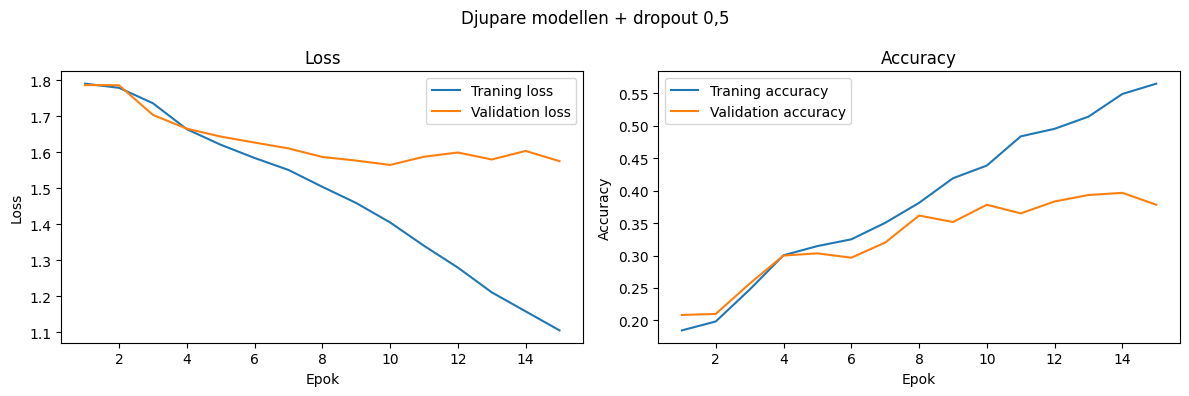

                          name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
                     Basmodell        0.763750    0.699207      0.368333  2.015561          14      20.121974
                   Dropout 0.2        0.797917    0.611834      0.385000  1.893981          15      20.308429
                   Dropout 0.4        0.655833    0.934150      0.378333  1.731448          14      21.269195
                   Dropout 0.5        0.588333    1.089161      0.390000  1.631879          15      20.843831
                       L2 0.01        0.346250    1.662501      0.301667  1.743431          15      22.789530
                      L2 0.001        0.506250    1.367846      0.361667  1.719191          10      22.834726
                     L2 0.0001        0.717500    0.850400      0.376667  1.955794          14      22.673230
                     LR 0.0001        0.415417    1.513549      0.358333  1.626718           9      20.556034
          

In [19]:
# Experiment med djupare modell och dropout 0,5
model_deep_dropout, h_deep_dropout, r_deep_dropout = run_experiment(
    "Djupare modellen + dropout 0,5",
    dropout_rate=0.5,
    num_filters_3=128
)

results.append(r_deep_dropout)
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

Med dropout 0,5 så får den bredare modellen en något lägre accuracy på valideringsdatan men också lägre loss. Den djupare modellen med dropout 0,5 får den högsta accuracy på valideringsdatan hittils och lägre loss än när den körde utan dropout. Träningskurvorna är också de som visar minst överanpassning av alla experiment på subsetet.

Nästa steg är att testa basmodellen, den bredare och den djupare modellen, alla med dropout 0,5, på hela träningsdatan.

### Träna modellen på hela träningsdatan

Förutom att testa basmodellen, den bredare och den djupare modellen, alla med dropout 0,5, så körs även en kombination av den breda och den djupa modellen på hela träningsdatan. 

In [20]:
# Skapa tränings- och valideringsuppsättningar med alla bilder (utan disgust)
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.20,
    random_state=42,
    stratify=y_filtered
)

# Utskrift för kontroll av shapes i train/val-split
print("X_train:", X_train_full.shape)
print("X_val:", X_val_full.shape)
print("y_train:", y_train_full.shape)
print("y_val:", y_val_full.shape)

X_train: (22618, 48, 48, 1)
X_val: (5655, 48, 48, 1)
y_train: (22618,)
y_val: (5655,)


#### Funktion för att jämföra modeller som körts på subset och hela träningsdatan

In [21]:
# Jämför en modells resultat på subset vs full träningsdata
def compare_subset_vs_full(name_subset, r_subset, name_full, r_full):
    """
    Skapar en DataFrame för att jämföra resultat mellan en modell tränad på subset vs samma modell tränad på hela datan.
    """
    df = pd.DataFrame([
        {"Modell": name_subset,
         "Training Accuracy": r_subset["train_accuracy"],
         "Training Loss": r_subset["train_loss"],
         "Validation Accuracy": r_subset["val_accuracy"],
         "Validation Loss": r_subset["val_loss"]},
        {"Modell": name_full,
         "Training Accuracy": r_full["train_accuracy"],
         "Training Loss": r_full["train_loss"],
         "Validation Accuracy": r_full["val_accuracy"],
         "Validation Loss": r_full["val_loss"]}
    ])
    return df.style\
        .format({"Validation Accuracy": "{:.1%}", "Validation Loss": "{:.4f}"})\
        .background_gradient(subset=["Validation Accuracy"], cmap="RdYlGn")


Experiment: Basmodellen + dropout 0,5 på hela träningsdatan
Antal epoker: 15
Training accuracy: 0.5996
Training loss: 1.0146
Validation accuracy: 0.5114
Validation loss: 1.3687
Träningstid: 181.32 sekunder


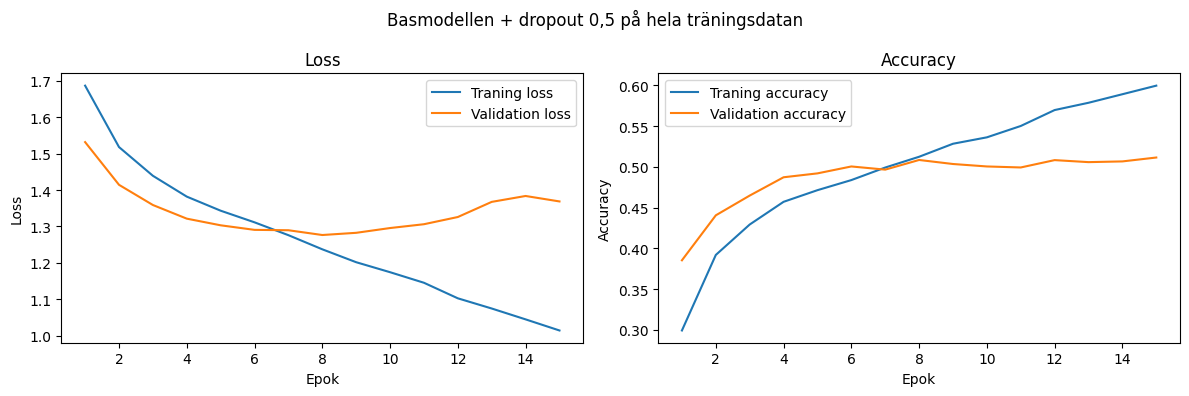

                                           name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
                                      Basmodell        0.763750    0.699207      0.368333  2.015561          14      20.121974
                                    Dropout 0.2        0.797917    0.611834      0.385000  1.893981          15      20.308429
                                    Dropout 0.4        0.655833    0.934150      0.378333  1.731448          14      21.269195
                                    Dropout 0.5        0.588333    1.089161      0.390000  1.631879          15      20.843831
                                        L2 0.01        0.346250    1.662501      0.301667  1.743431          15      22.789530
                                       L2 0.001        0.506250    1.367846      0.361667  1.719191          10      22.834726
                                      L2 0.0001        0.717500    0.850400      0.376667  1.955794          14

In [22]:
# Bygger och tränar en modell med alla träningsbilder (utan disgust)
X_train = X_train_full
X_val = X_val_full
y_train = y_train_full
y_val = y_val_full

model_bas_full, h_bas_full, r_bas_full = run_experiment(
    "Basmodellen + dropout 0,5 på hela träningsdatan",
    dropout_rate=0.5,
)

results.append(r_bas_full)
print(pd.DataFrame(results).to_string(index=False))

In [23]:
# Jämför resultat mellan modellen på subsetet och modellen på hela träningsdatan
compare_subset_vs_full(
    "Basmodellen + dropout 0,5 med subset", r_bas,
    "Basmodellen + dropout 0,5 med hela träningsdatan", r_bas_full
)

,Modell,Training Accuracy,Training Loss,Validation Accuracy,Validation Loss
0,"Basmodellen + dropout 0,5 med subset",0.763750,0.699207,36.8%,2.0156
1,"Basmodellen + dropout 0,5 med hela träningsdatan",0.599567,1.014602,51.1%,1.3687


#### Kommentar

Med hela träningsdatan förbättras accuracy på valideringsdatan från 36,8% till 51,1% vilket är en markant förbättring jämfört med tidigare experiment som visar att mer data hjälper modellen att generalisera bättre. Kurvorna visar att modellen fortfarande överanpassar då loss på valideringsdatan bärjar sita runt epok 8 - 10 men accuracy planar ut på en högre nivå än med subsetet. Detta tyder på att datamängd är en viktig faktor för denna typ av problem.


Experiment: Bredare modellen + dropout 0,5 på hela träningsdatan
Antal epoker: 15
Training accuracy: 0.7095
Training loss: 0.7706
Validation accuracy: 0.5333
Validation loss: 1.4131
Träningstid: 521.72 sekunder


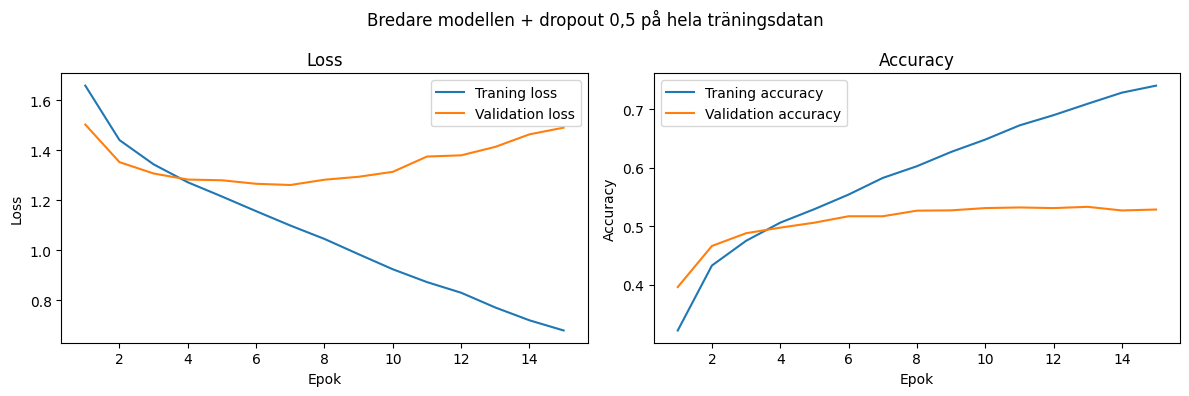

                                                name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
                                           Basmodell        0.763750    0.699207      0.368333  2.015561          14      20.121974
                                         Dropout 0.2        0.797917    0.611834      0.385000  1.893981          15      20.308429
                                         Dropout 0.4        0.655833    0.934150      0.378333  1.731448          14      21.269195
                                         Dropout 0.5        0.588333    1.089161      0.390000  1.631879          15      20.843831
                                             L2 0.01        0.346250    1.662501      0.301667  1.743431          15      22.789530
                                            L2 0.001        0.506250    1.367846      0.361667  1.719191          10      22.834726
                                           L2 0.0001        0.717500    0.85

In [24]:
# Bygger och tränar en bredare modell med alla träningsbilder (utan disgust)
model_broad_full, h_broad_full, r_broad_full = run_experiment(
    "Bredare modellen + dropout 0,5 på hela träningsdatan",
    num_filters_1=64,
    num_filters_2=128,
    dense_units=256,
    dropout_rate=0.5,
)

results.append(r_broad_full)
print(pd.DataFrame(results).to_string(index=False))

In [25]:
# Jämför resultat mellan den bredare modellen på subsetet och den bredare modellen på hela träningsdatan
compare_subset_vs_full(
    "Bredare modellen + dropout 0,5 med subset", r_broad,
    "Bredare modellen + dropout 0,5 med hela träningsdatan", r_broad_full
)

,Modell,Training Accuracy,Training Loss,Validation Accuracy,Validation Loss
0,"Bredare modellen + dropout 0,5 med subset",0.704167,0.834707,39.0%,1.8962
1,"Bredare modellen + dropout 0,5 med hela träningsdatan",0.709479,0.770616,53.3%,1.4131


#### Kommentar

Den bredare modellen med dropout 0,5 på hela träningsdatan förbättras från 39,0% till 53,3% jämfört med subsetet, vilket igen visar att mer data hjälper. Jämfört med basmodellen med dropout 0,5 gav den en marginell förbättring på +2,2 procentenheter i accuracy på valideringsdatan men tar tre gånger så lång tid att träna och börjar överanpassa tidigare, runt epok 6–8. Detta tyder på att en bredare arkitektur inte är den mest effektiva lösningen för detta problem.


Experiment: Djupare modellen + dropout 0,5 på hela träningsdatan
Antal epoker: 15
Training accuracy: 0.6406
Training loss: 0.9384
Validation accuracy: 0.5618
Validation loss: 1.2080
Träningstid: 214.24 sekunder


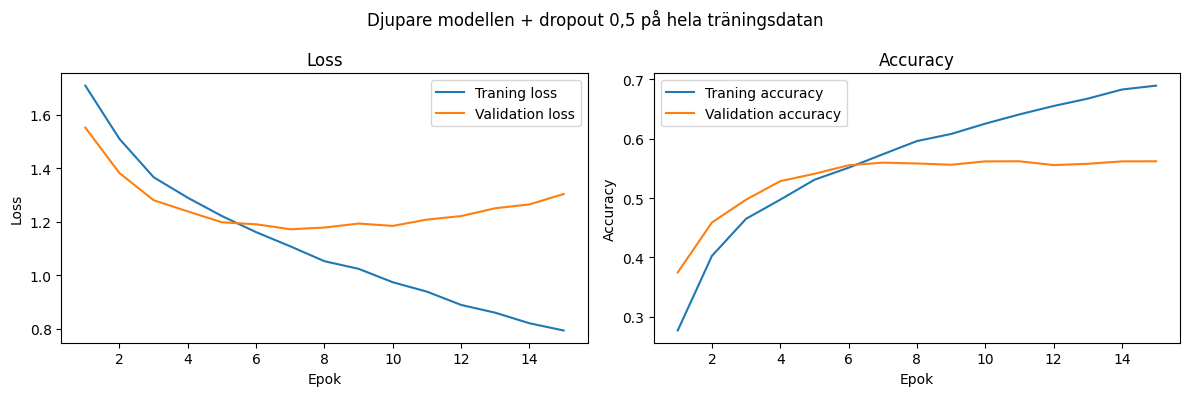

                                                name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
                                           Basmodell        0.763750    0.699207      0.368333  2.015561          14      20.121974
                                         Dropout 0.2        0.797917    0.611834      0.385000  1.893981          15      20.308429
                                         Dropout 0.4        0.655833    0.934150      0.378333  1.731448          14      21.269195
                                         Dropout 0.5        0.588333    1.089161      0.390000  1.631879          15      20.843831
                                             L2 0.01        0.346250    1.662501      0.301667  1.743431          15      22.789530
                                            L2 0.001        0.506250    1.367846      0.361667  1.719191          10      22.834726
                                           L2 0.0001        0.717500    0.85

In [26]:
# Bygger och tränar en djupare modell med alla träningsbilder (utan disgust)
model_deep_full, h_deep_full, r_deep_full = run_experiment(
    "Djupare modellen + dropout 0,5 på hela träningsdatan",
    dropout_rate=0.5,
    num_filters_3=128
)

results.append(r_deep_full)
print(pd.DataFrame(results).to_string(index=False))

In [27]:
# Jämför resultat mellan den djupare modellen på subsetet och den djupare modellen på hela träningsdatan
compare_subset_vs_full(
    "Djupare modellen + dropout 0,5 med subset", r_deep,
    "Djupare modellen + dropout 0,5 med hela träningsdatan", r_deep_full
)

,Modell,Training Accuracy,Training Loss,Validation Accuracy,Validation Loss
0,"Djupare modellen + dropout 0,5 med subset",0.686250,0.852518,39.0%,1.8504
1,"Djupare modellen + dropout 0,5 med hela träningsdatan",0.640640,0.938442,56.2%,1.2080


### Kommentar

Den djupare modellen med dropout 0,5 på hela träningsdatan förbättras från 39,0% till 56,2% jämfört med subsetet, vilket är den högsta accuracyn hittils. Den går också dubbelt så fort att träna som den bredare modellen. Den börjar överanpassa runt epok 7 - 9 men gapet mellan accuracy på tränings- och valideringsdatan är mindre än för den breda modellen. Sammantaget indikerar detta att en djupare modell är rätt väg att gå för detta problem.


Experiment: Maxade modellen + dropout 0,5 på hela träningsdatan
Antal epoker: 15
Training accuracy: 0.6606
Training loss: 0.8875
Validation accuracy: 0.5524
Validation loss: 1.3391
Träningstid: 579.35 sekunder


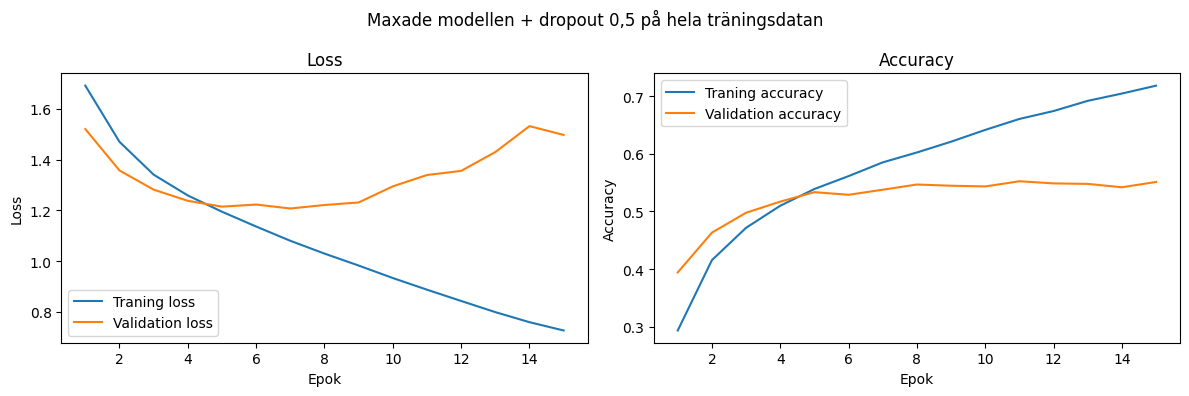

                                                name  train_accuracy  train_loss  val_accuracy  val_loss  best_epoch  training_time
                                           Basmodell        0.763750    0.699207      0.368333  2.015561          14      20.121974
                                         Dropout 0.2        0.797917    0.611834      0.385000  1.893981          15      20.308429
                                         Dropout 0.4        0.655833    0.934150      0.378333  1.731448          14      21.269195
                                         Dropout 0.5        0.588333    1.089161      0.390000  1.631879          15      20.843831
                                             L2 0.01        0.346250    1.662501      0.301667  1.743431          15      22.789530
                                            L2 0.001        0.506250    1.367846      0.361667  1.719191          10      22.834726
                                           L2 0.0001        0.717500    0.85

In [28]:
# Bygger och tränar en maxad modell med alla träningsbilder (utan disgust)
model_max_full, h_max_full, r_max_full = run_experiment(
    "Maxade modellen + dropout 0,5 på hela träningsdatan",
    num_filters_1=64,
    num_filters_2=128,
    num_filters_3=128,
    dense_units=256,
    dropout_rate=0.5,
)

results.append(r_max_full)
print(pd.DataFrame(results).to_string(index=False))

### Kommentar

Den maxade modellen har näst bäst accuracy på valideringsdatan -1 procentenheter jämfört med den djupa modellen. Den har ett något större gap mellan tränings- och valideringsdatan och den tar mer än dubbelt så lång tid att träna och överanpassar mer. Att modellen inte blir bättre av att ha fler filter och noder tyder på att det inte är det som behövs för att analysera de komplexa mönster som ansiktsuttryck är.

In [29]:
# Skapar en DataFrame för att på tydligt vis presentera resultatet från samtliga experiment
display(pd.DataFrame(results)
    .sort_values("val_accuracy", ascending=False)
    .style.format({
    "train_accuracy": "{:.4f}",
    "train_loss": "{:.4f}",
    "val_accuracy": "{:.4f}",
    "val_loss": "{:.4f}",
    "best_epoch": "{:.0f}",
    "training_time": "{:.1f}s"
}).highlight_max(subset=["val_accuracy"], color="darkgreen")
  .highlight_min(subset=["val_loss"], color="darkblue")
  .set_caption("Sammanfattning av alla experiment")
  .set_table_styles([{"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]}]))

,name,train_accuracy,train_loss,val_accuracy,val_loss,best_epoch,training_time
16,"Djupare modellen + dropout 0,5 på hela träningsdatan",0.6406,0.9384,0.5618,1.2080,11,214.2s
17,"Maxade modellen + dropout 0,5 på hela träningsdatan",0.6606,0.8875,0.5524,1.3391,11,579.4s
15,"Bredare modellen + dropout 0,5 på hela träningsdatan",0.7095,0.7706,0.5333,1.4131,13,521.7s
14,"Basmodellen + dropout 0,5 på hela träningsdatan",0.5996,1.0146,0.5114,1.3687,15,181.3s
13,"Djupare modellen + dropout 0,5",0.5492,1.1582,0.3967,1.6040,14,26.7s
3,Dropout 0.5,0.5883,1.0892,0.3900,1.6319,15,20.8s
10,Bredare modell,0.7042,0.8347,0.3900,1.8962,10,62.4s
11,Djupare modell,0.6862,0.8525,0.3900,1.8504,13,29.6s
12,"Bredare modellen + dropout 0,5",0.7088,0.7690,0.3883,1.8341,15,61.4s
1,Dropout 0.2,0.7979,0.6118,0.3850,1.8940,15,20.3s


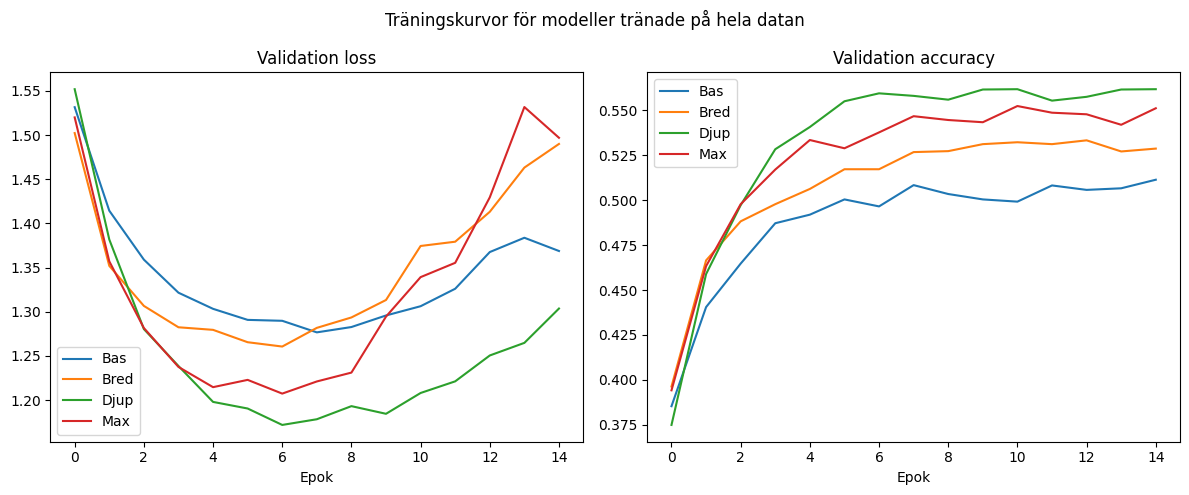

In [30]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(h_bas_full.history["val_loss"], label="Bas")
plt.plot(h_broad_full.history["val_loss"], label="Bred")
plt.plot(h_deep_full.history["val_loss"], label="Djup")
plt.plot(h_max_full.history["val_loss"], label="Max")
plt.xlabel("Epok")
plt.title("Validation loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h_bas_full.history["val_accuracy"], label="Bas")
plt.plot(h_broad_full.history["val_accuracy"], label="Bred")
plt.plot(h_deep_full.history["val_accuracy"], label="Djup")
plt.plot(h_max_full.history["val_accuracy"], label="Max")
plt.xlabel("Epok")
plt.title("Validation accuracy")
plt.legend()

plt.suptitle("Träningskurvor för modeller tränade på hela datan")
plt.tight_layout()
plt.show()

#### Sammanfattning experiment med hela träningsdatan

Resultaten visar att mer data är den viktigaste faktorn för förbättring då alla modeller presterade bättre på hela träningsdatan än på subsetet. Den djupare modellen med ett extra Conv2D-lager gav bäst accuracy på valideringsdatan, 56,2%, bättre än den som kombinerade mer bredd och djup, vilket tyder på att ökad djup gynnas av mer data medan ökad bredd inte hjälpte lika mycket. Detta syns tydligt i jämförelsegraferna där den djupa modellen (grön) håller en stabilt lägre validation loss och högre validation accuracy genom hela träningen jämfört med de övriga. Detta kan bero på att fler Conv2D-lager bygger upp en allt mer avancerad mönsterförståelse medan fler filter lär sig fler varianter av mönster på samma nivå.

In [31]:
# Sparar den bästa modellen (den djupare modellen med dropout tränad på hela datan) i Keras-format
final_model = model_deep_full
final_model.save("final_model.keras")

### Felanalys på valideringsdatan

För att förstå var modellen misslyckas analyseras prediktionerna på valideringsdatan. Konfusionsmatrisen visar hur många bilder som klassificerats rätt respektive fel per klass, och per-klass accuracy identifierar vilka känslor som är svårast att känna igen. Slutligen visas exempel på felklassificerade bilder tillsammans med modellens säkerhet.

#### Funktion för prediktion och sannolikhet

In [32]:
def predict_classes(model, X):

    """
    Returnerar predikterade klasser och sannolikheter för en modell.
    """
    
    y_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    return y_pred, y_proba

In [33]:
# Predikterar klasser och sannolikheter på valideringsdatan
final_model_val_pred, final_model_val_proba = predict_classes(final_model, X_val)

#### Funktion för att plotta konfusionsmatris

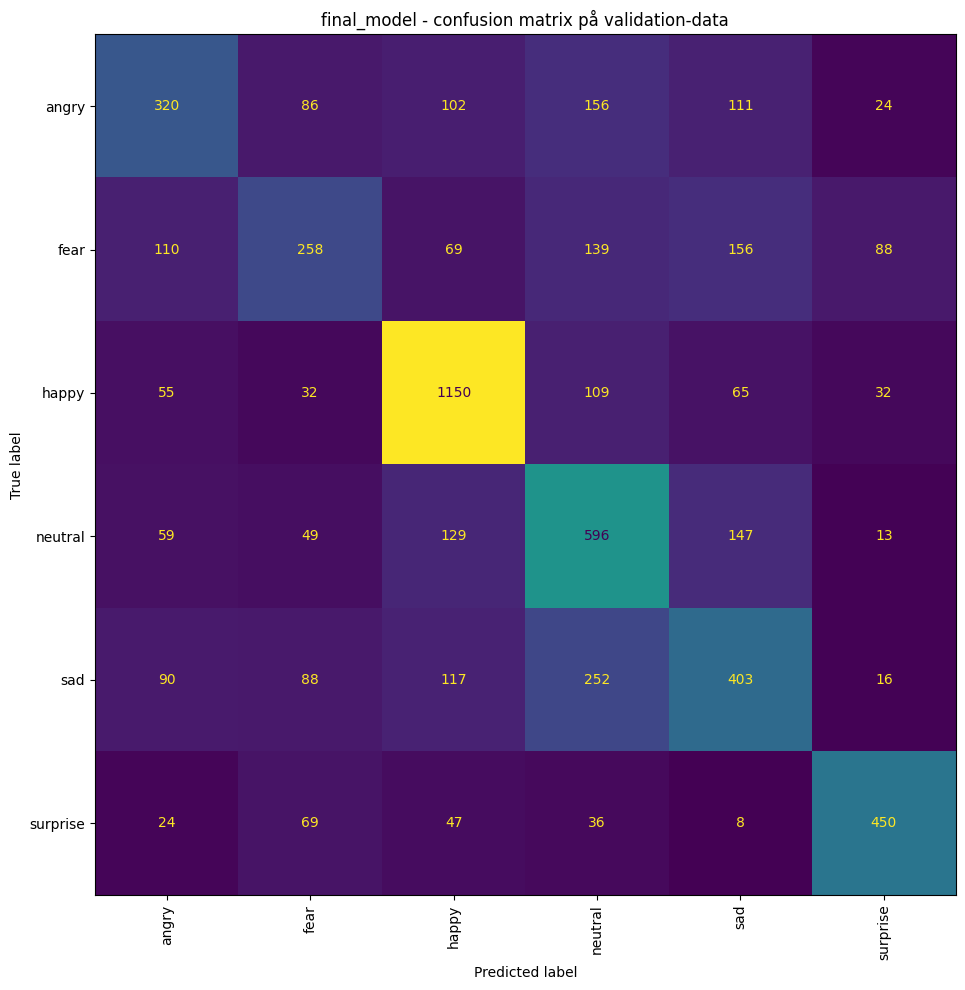

In [34]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion matrix"):

    """
    Plottar en konfusionsmatris och returnerar den som numpy-array.
    """

    labels = np.arange(len(class_names))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    fig, ax = plt.subplots(figsize=(12, 10))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    display.plot(
        ax=ax,
        xticks_rotation=90,
        values_format="d",
        colorbar=False
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return cm

# Konfusionsmatris på valideringsdatan
final_model_cm = plot_confusion_matrix(
    y_val,
    final_model_val_pred,
    class_names_filtered,
    title="final_model - confusion matrix på validation-data")

#### Kommentar

Happy har det högsta diagonalvärdet vilket indikerar att modellen känner igen den klassen bra. Angry och fear har lägst diagonalvärden och sprids ut över flera klasser och verkar svårast för modellen att klassificera korrekt.

#### Funktion för att beräkna accuracy för respektive klass

In [35]:
def calculate_per_class_accuracy(cm, class_names):

    """
    Beräknar accuracy per klass från en konfusionsmatris.
    Returnerar en DataFrame sorterad efter accuracy (lägst först).
    """

    support = cm.sum(axis=1)
    correct = np.diag(cm)

    accuracy = correct / support

    result = pd.DataFrame({
        "class_id": np.arange(len(class_names)),
        "class_name": class_names,
        "support": support,
        "correct": correct,
        "accuracy": accuracy
    })

    return result.sort_values("accuracy")


final_model_per_class = calculate_per_class_accuracy(
    final_model_cm,
    class_names_filtered
)

print("Per-klass accuracy på valideringsdata")

# Per-klass accuracy sorterad från sämst till bäst
final_model_per_class.style\
    .format({"accuracy": "{:.1%}"})\
    .background_gradient(subset=["accuracy"], cmap="RdYlGn")

Per-klass accuracy på valideringsdata


,class_id,class_name,support,correct,accuracy
1,1,fear,820,258,31.5%
0,0,angry,799,320,40.1%
4,4,sad,966,403,41.7%
3,3,neutral,993,596,60.0%
5,5,surprise,634,450,71.0%
2,2,happy,1443,1150,79.7%


#### Kommentar

Happy, 80% och surprise, 71% är lättast medan fear, 32% och angry, 40% är svårast. Skillnaden på 44 procentenheter mellan bästa och sämsta klass är stor.

#### Funktion för att visa de vanligaste felklassificeringarna

In [36]:
def get_most_confused_pairs(cm, class_names, top_n=10):

    """
    Returnerar de vanligaste felklassificeringarna som en DataFrame.
    Sorterad efter antal fel, högst först.
    """

    pairs = []

    for true_class in range(cm.shape[0]):
        for predicted_class in range(cm.shape[1]):
            if true_class == predicted_class:
                continue

            count = cm[true_class, predicted_class]

            if count > 0:
                pairs.append({
                    "true_class_id": true_class,
                    "true_class": class_names[true_class],
                    "predicted_class_id": predicted_class,
                    "predicted_class": class_names[predicted_class],
                    "count": count
                })

    pairs_df = pd.DataFrame(pairs)

    if pairs_df.empty:
        return pairs_df

    return pairs_df.sort_values("count", ascending=False).head(top_n)

final_model_confusions = get_most_confused_pairs(
    final_model_cm,
    class_names_filtered
)

print("Mest felklassificerade par på valideringsdata")

# De 10 vanligaste felklassificeringarna
final_model_confusions.style\
    .background_gradient(subset=["count"], cmap="RdYlGn_r")


Mest felklassificerade par på valideringsdata


,true_class_id,true_class,predicted_class_id,predicted_class,count
23,4,sad,3,neutral,252
2,0,angry,3,neutral,156
8,1,fear,4,sad,156
18,3,neutral,4,sad,147
7,1,fear,3,neutral,139
17,3,neutral,2,happy,129
22,4,sad,2,happy,117
3,0,angry,4,sad,111
5,1,fear,0,angry,110
12,2,happy,3,neutral,109


#### Kommentar

Sad och angry förväxlas ofta med neutral, och sad förväxlas även med fear.

#### Funktion för att skriva ut felklassificerade bilder

Antal felklassificerade exempel: 2478


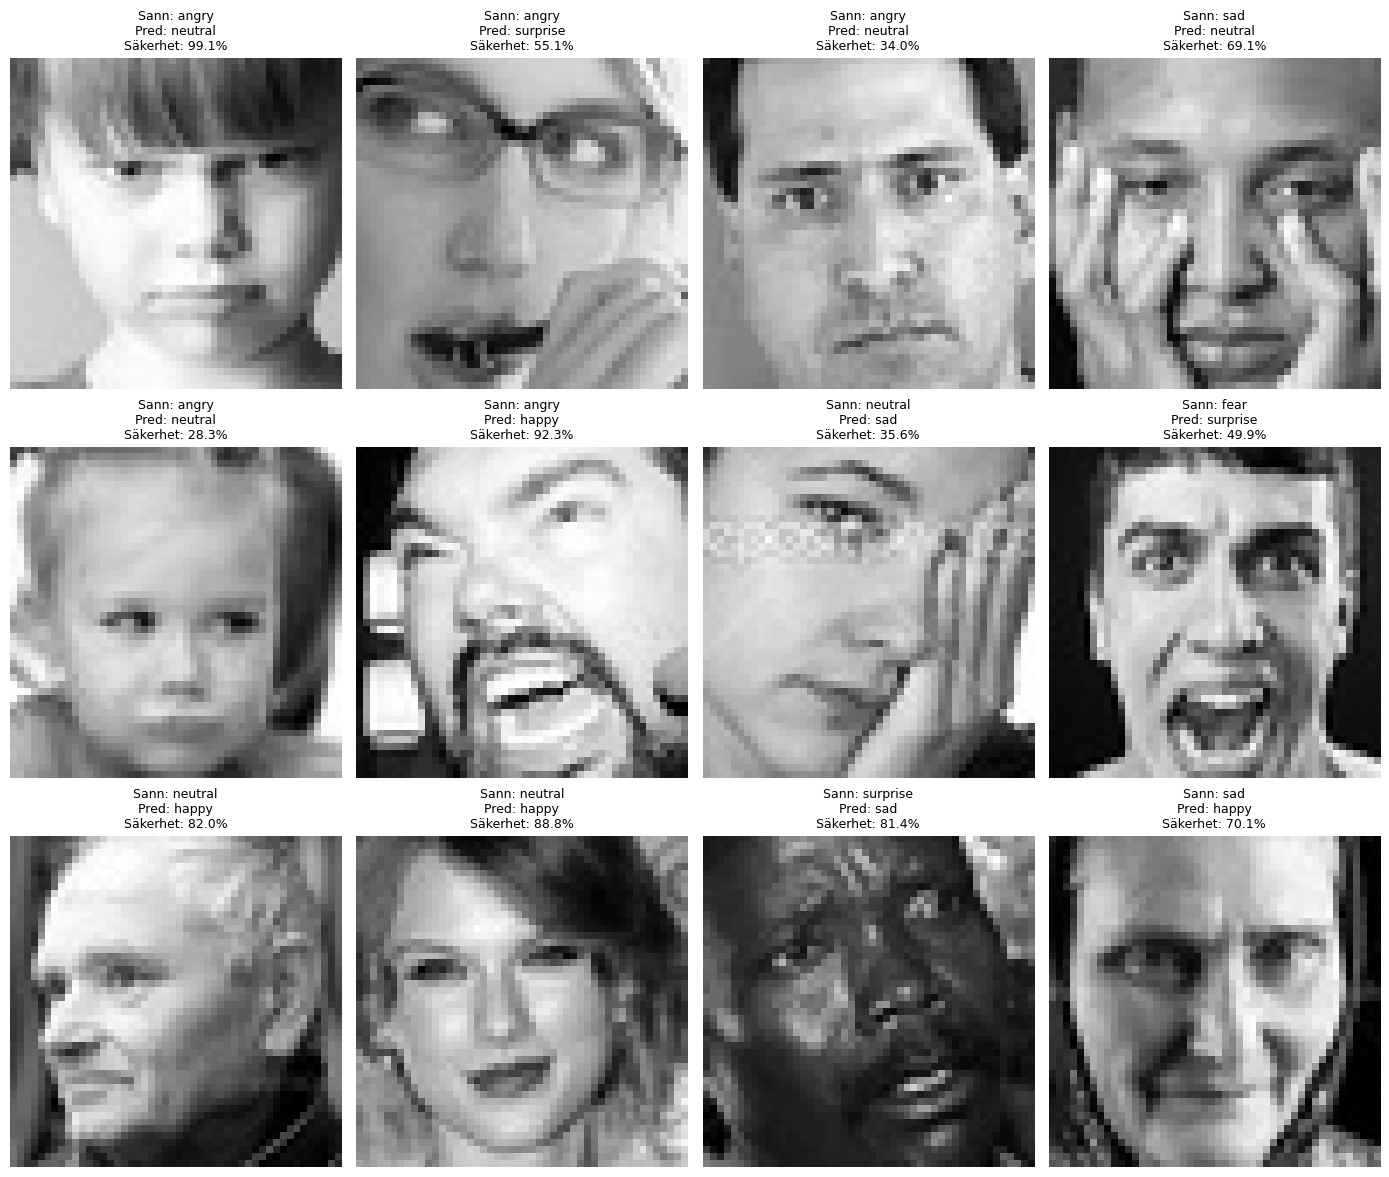

In [37]:
def plot_misclassified_examples(
    X,
    y_true,
    y_pred,
    y_proba,
    class_names,
    n_images=12,
    random_state=42
):
    
    """
    Visar slumpmässigt utvalda felklassificerade bilder med sann klass,
    predikterad klass och modellens säkerhet.
    """

    error_indices = np.where(y_true != y_pred)[0]

    print(f"Antal felklassificerade exempel: {len(error_indices)}")

    if len(error_indices) == 0:
        print("Inga felklassificerade exempel att visa.")
        return

    rng = np.random.default_rng(random_state)

    chosen_indices = rng.choice(
        error_indices,
        size=min(n_images, len(error_indices)),
        replace=False
    )

    cols = 4
    rows = int(np.ceil(len(chosen_indices) / cols))

    plt.figure(figsize=(14, 4 * rows))

    for plot_index, data_index in enumerate(chosen_indices):
        true_label = y_true[data_index]
        pred_label = y_pred[data_index]
        confidence = y_proba[data_index, pred_label] * 100

        plt.subplot(rows, cols, plot_index + 1)
        plt.imshow(X[data_index].squeeze(), cmap="gray")
        plt.title(
            f"Sann: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}\n"
            f"Säkerhet: {confidence:.1f}%",
            fontsize=9
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Visar 12 slumpmässiga felklassificeringar med sann klass och modellens säkerhet
plot_misclassified_examples(
    X_val,
    y_val,
    final_model_val_pred,
    final_model_val_proba,
    class_names_filtered,
    n_images=12,
    random_state=42
)

#### Kommentar

Flera av de felklassificerade bilderna är svåra att tolka även för en människa, som bilder med text eller händer framför ansiktet, bilder från sidan eller otydliga uttryck. 

#### Sammanfattning felanalys på valideringsdata

Modellen presterar bäst på känslouttryck som happy och surprise men kämpar med uttryck som fear och angry. En del fel kan förklaras av bildkvalitet och ovanliga vinklar snarare än modellens begränsningar.

## 5. Utvärdera modellen

Den slutliga modellen utvärderas på testdatan som inte använts under träning eller experimentfasen. Testdatan ger ett objektivt mått på hur väl modellen generaliserar till ny data. Resultaten jämförs med valideringsdatan för att kontrollera att modellen inte är överanpassad till valideringsdatan.

In [38]:
# Laddar sparad modell och utvärderar på testdata
final_model = keras.models.load_model("final_model.keras")

test_loss, test_accuracy = final_model.evaluate(X_test_filtered, y_test_filtered, verbose=0)

# Jämför resultat på validerings- och testdata
comparison_overall = pd.DataFrame([
    {"dataset": "Validering", "accuracy": r_deep_full["val_accuracy"], "loss": r_deep_full["val_loss"]},
    {"dataset": "Test", "accuracy": test_accuracy, "loss": test_loss}
])

comparison_overall.style\
    .format({"accuracy": "{:.1%}", "loss": "{:.4f}"})\
    .background_gradient(subset=["accuracy"], cmap="RdYlGn")

,dataset,accuracy,loss
0,Validering,56.2%,1.2080
1,Test,55.8%,1.3291


### Prediktion, sannolikhet och felanalys på testdata

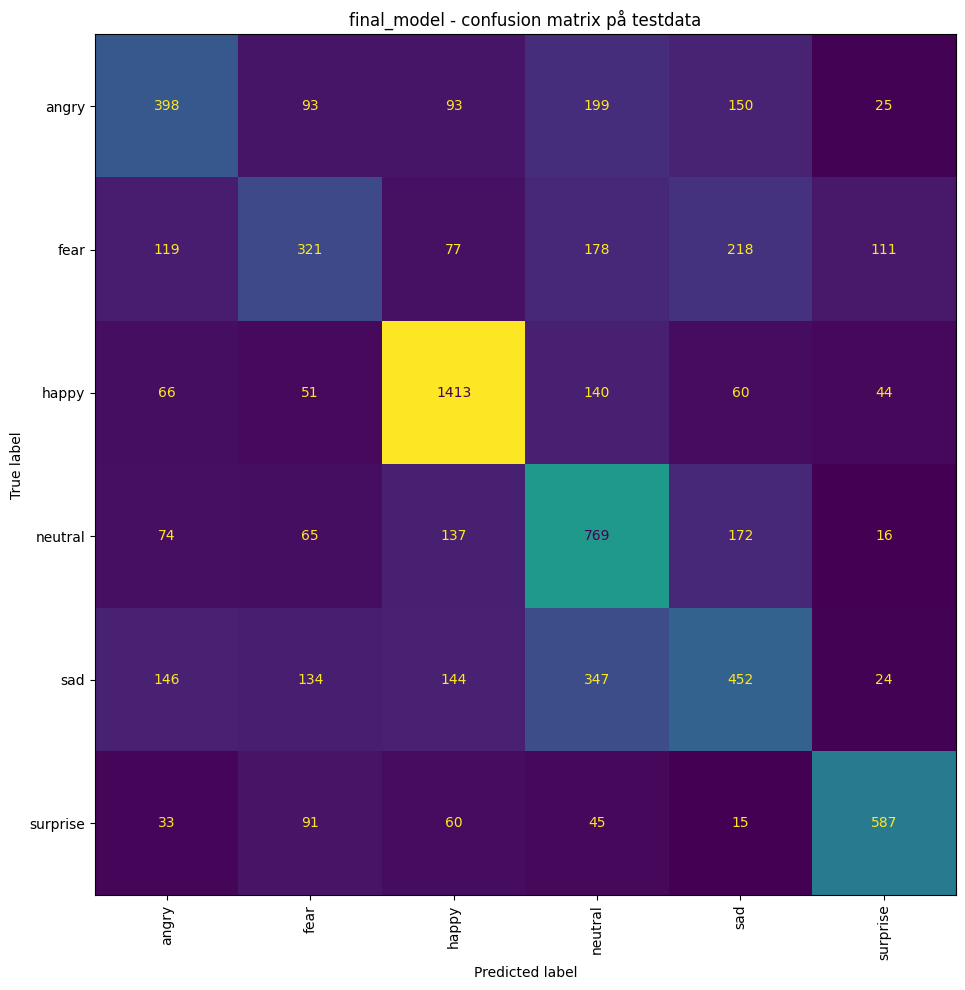

In [39]:
# Predikterar på testdata
test_pred, test_proba = predict_classes(final_model, X_test_filtered)

# Konfusionsmatris på testdata
final_model_test_cm = plot_confusion_matrix(
    y_test_filtered,
    test_pred,
    class_names_filtered,
    title="final_model - confusion matrix på testdata"
)

# Per-klass accuracy på testdata
final_model_test_per_class = calculate_per_class_accuracy(
    final_model_test_cm,
    class_names_filtered
)

#### Kommentar

Mönstret liknar valideringsdatan happy har störst diagonalvärden medan angry och fear sprids ut över flera klasser.

In [40]:
# Jämför per-klass accuracy mellan validerings- och testdata
comparison = final_model_per_class[["class_name", "accuracy"]].merge(
    final_model_test_per_class[["class_name", "accuracy"]],
    on="class_name",
    suffixes=("_val", "_test")
)

comparison.sort_values("accuracy_test").style\
    .format({"accuracy_val": "{:.1%}", "accuracy_test": "{:.1%}"})\
    .background_gradient(subset=["accuracy_val", "accuracy_test"], cmap="RdYlGn")

,class_name,accuracy_val,accuracy_test
0,fear,31.5%,31.3%
2,sad,41.7%,36.2%
1,angry,40.1%,41.5%
3,neutral,60.0%,62.4%
4,surprise,71.0%,70.6%
5,happy,79.7%,79.7%


#### Kommentar

Per-klass accuracy är nästan identisk mellan validerings- och testdata, vilket bekräftar att modellen generaliserar bra. Happy är bäst med 
79,7% på båda, följt av surprise (~71%) och neutral (~61%). Fear är sämst med ~31% på båda. Det enda något större avvikelsen är sad som 
sjunker från 41,7% till 36,2% på testdata, vilket tyder på att sad är något svårare att generalisera.

Antal felklassificerade exempel: 3127


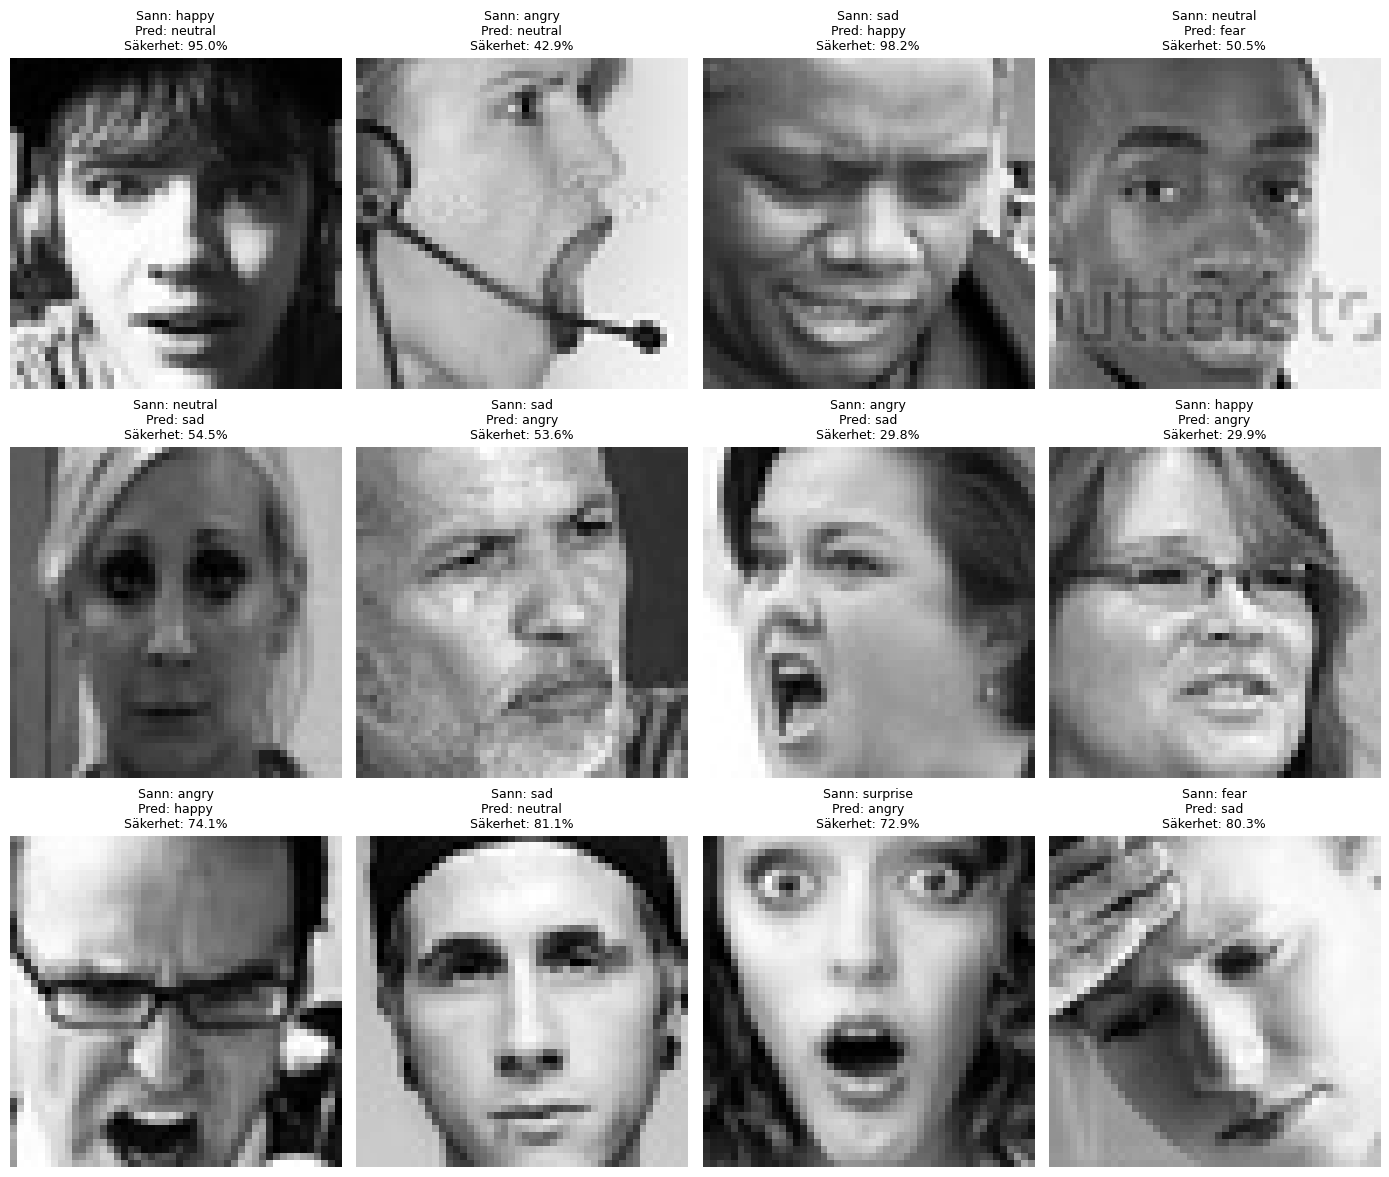

In [41]:
# Visar 12 slumpmässiga felklassificeringar från testdata med sann klass och modellens säkerhet
plot_misclassified_examples(
    X_test_filtered,
    y_test_filtered,
    test_pred,
    test_proba,
    class_names_filtered,
    n_images=12,
    random_state=42
)

#### Kommentar

Flera av de felklassificerade bilderna är svåra att tolka även för en människa, bilder tagna från sidan, med text eller händer framför ansiktet eller med tvetydiga uttryck. 
Detta speglar utmaningen med FER-2013 där bildkvalitet och subjektiva labels påverkar resultatet.

#### Sammanfattning felanalys på testdata

Felanalysen på testdatan bekräftar bilden från valideringsdatan. Modellen är konsekvent i sina styrkor och svagheter, vilket tyder på god generalisering snarare än överanpassning till valideringsdatan.

## 6. Gör prediktioner på ny data

För att visa att modellen fungerar som ett program används den för att klassificera en enskild bild från testdatan. Bilden förbereds på samma sätt som träningsdatan och modellen returnerar en sannolikhet för varje känslouttryck. Den klass med högst sannolikhet är modellens prediktion.

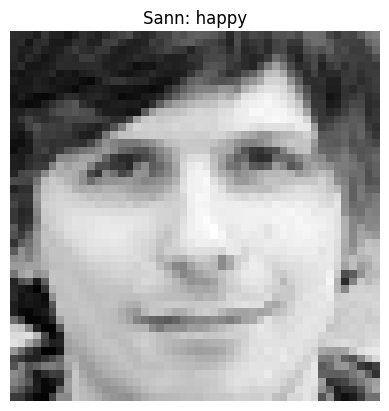

Sann label: happy
Predikterad label: happy


,Klass,Sannolikhet %
2,happy,75.9
3,neutral,24.1
4,sad,0.0
0,angry,0.0
5,surprise,0.0
1,fear,0.0


In [42]:
# Prediktion på en enskild bild från testdatan (index 2001)
# Visar bilden, sann klass, predikterad klass och sannolikhet per klass
image_index = 2001

probabilities = pd.DataFrame({
    "Klass": class_names_filtered,
    "Sannolikhet": test_proba[image_index]
})

probabilities = probabilities.sort_values(
    by="Sannolikhet",
    ascending=False
)

probabilities["Sannolikhet %"] = (probabilities["Sannolikhet"] * 100).round(2)

plt.imshow(X_test_filtered[image_index].squeeze(), cmap="gray")
plt.axis("off")
plt.title(f"Sann: {class_names_filtered[y_test_filtered[image_index]]}")
plt.show()

print("Sann label:", class_names_filtered[y_test_filtered[image_index]])
print("Predikterad label:", class_names_filtered[test_pred[image_index]])
probabilities[["Klass", "Sannolikhet %"]].style\
    .format({"Sannolikhet %": "{:.1f}"})\
    .background_gradient(subset=["Sannolikhet %"], cmap="RdYlGn")

### Kommentar

Modellen klassificerade bilden korrekt som happy med 75,9% säkerhet.

### Funktion för att prediktera nya bilder

In [43]:
# Prediktion på egna bilder
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_multiple_images(model, class_names, image_paths):
    """
    Visar flera egna bilder bredvid varandra med predikterad klass.
    """
    n = len(image_paths)
    plt.figure(figsize=(4 * n, 4))
    
    for i, path in enumerate(image_paths):
        img = load_img(path, color_mode="grayscale", target_size=(48, 48))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        
        pred_label, pred_proba = predict_classes(model, img_array)
        confidence = pred_proba[0].max() * 100
        
        plt.subplot(1, n, i + 1)
        plt.imshow(img_array.squeeze(), cmap="gray")
        plt.title(f"Pred: {class_names[pred_label[0]]}\n{confidence:.1f}%", fontsize=9)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

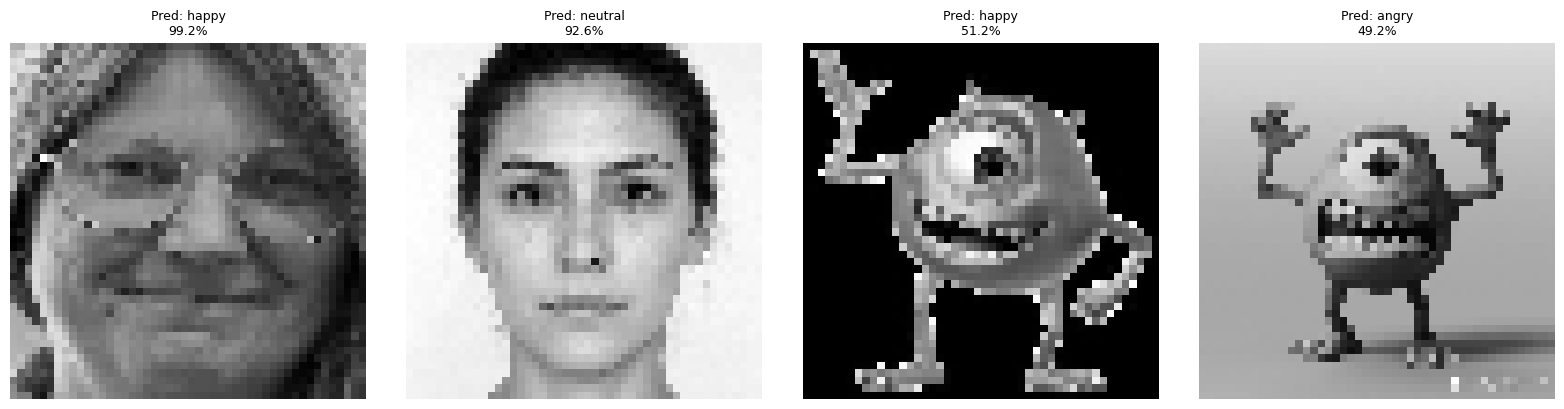

In [44]:
predict_multiple_images(final_model, class_names_filtered, [
    "images/egen_testbild.jpg",
    "images/ai_testbild.jpg",
    "images/mike_wazowski_happy.jpg",
    "images/mike_wazowski_angry.jpg"
])

### Kommentar

Modellen klassificerade den egna bilden som happy med 99,2% säkerhet. Happy är den klass som modellen är bästa på. Den AI-genererade bilden klassificerades också som neutral, vilket får anses rätt. Mike Wazowski klassificerades som happy med 51.2%, trots att happy är modellens paradgren så var den inte så säker när det gäller Mikes leende vilket kanske inte är orimligt givet hans stora öga och tandade leende. Den var endast 49,2% säker på hans arga uttryck vilket ändå är lite högre än accuracy för angry på testdatan.

## 7. Analysera resultatet
 
**Hur bra fungerar modellen?**  
Den modell som valdes som bäst var den djupare modellen med tre Conv2D-lager och dropout 0,5. Modellen fick 56,2% accuracy på valideringsdatan och 55,8% på testdatan vilket visar att modellen generaliserar bra och inte har överanpassat till valideringsdatan. Dock är en accuracy på strax över 50% inte mycket bättre än att kasta mynt men för 6 klasser så är slumpen 16,7%. Ansiktsuttryck är svårt att klassificera så det är inte så överraskande och datasetet innehåller bilder med text eller händer framför ansiktet, bilder från sidan eller otydliga uttryck och ibland tveksamt om det ens är ansikten på bilderna.

55,8% är accuracy på alla klasser tillsammans och det är därför intressant att titta på accuracy för varje klass för sig. Här ser man en stor skillnad där happy har en accuracy på 80% , surprise på 71%, neutral på 62%, angry på 42%, sad på 36% och fear på 31%. Modellen presterar bäst på känslouttryck som happy och surprise men kämpar med uttryck som sad och fear.

Utskrift av felklassificerade bilder ger en inblick i svårigheten med datasetet. En del fel kan förklaras av bildkvalitet och ovanliga vinklar snarare än modellens begränsningar.

**Ser du tecken på overfitting eller underfitting?**  
Modellen överanpassade i alla experiment och regularisering med dropout 0,5 hade en något dämpande effekt. Med mer data så minskade gapet mellan accuracy på träningsdatan och valideringsdatan då den senare ökade markant. Exempelvis klassificerades tecknade ansikten med låg säkerhet vilket visar att modellen inte generaliserar utanför träningsfördelningen.

**Hur skiljer sig modellens resultat mellan träningsdata och testdata?**  
Resultat och fel var ganska lika mellan valideringsdatan med total accuracy på 56,2% och testdatan med total accuracy på 55,8%. Modellen hade något sämre accuracy på testdatan för klassen sad, 36,2%  jämfört med valideringsdatans 41,7%. Skillnaden i övriga klasser var mindre än så. Detta tyder på att modellen generaliserar bra på testdatan.

**Vad verkar påverka resultatet mest?** 
De genomförda experimenten tyder på att mängden träningsdata och en djupare arkitektur (fler Conv2D-lager) hade störst effekt. Regularisering med dropout 0,5 hade också en dämpande effekt på överanpassning.

**Vilka begränsningar har din modell?**  
Datasetet är utmanande både vad gäller bildkvalitet och eventuellt subjektiva labels. Modellen har också en relativt enkel arkitektur och skulle kunna göras djupare.

Deep learning lämpar sig bäst när det finns stora mängder märkt data och tillräcklig beräkningskraft. För ansiktsigenkänning är det ett rimligt val 
då mönstren i bilddata är komplexa, men med ett relativt litet dataset som FER-2013 kan enklare metoder eller transfer learning från förtränade modeller som VGG eller ResNet troligtvis ge bättre resultat.

## 8. Reflektion
  
**Vad var svårast i uppgiften?**  
Det svåraste var att hantera överanpassning då experimenten med regularisering gav begränsad effekt. Jag tycker även det var svårt med ett dataset där man själv ifrågasätter om det är rätt labels.  

**Vad lärde du dig?**  
Att datamängd ofta spelar större roll än modellkomplexitet, och att ansiktsuttryck är ett genuint svårt problem men där även enkla CNN når rimliga resultat.

**Vad hade du gjort annorlunda om du började om?**   
Med det jag lärt mig från de experiment jag gjort så skulle jag köra på hela datasetet från början och se om regularisering hade reducerat överanpassningen. Transfer learning med förtränade modeller som ResNet50 är något jag vill utforska vidare.

**Vilket betyg tycker du att din inlämning motsvarar, G eller VG?**    
VG. Jag har jämfört flera modellvarianter (basmodell, bredare modell och djupare modell) och systematiskt testat hyperparametrar (dropout, L2, learning rate). Resultaten analyseras med konfusionsmatris och per-klass accuracy, och jag för en kritisk diskussion om modellens begränsningar och när deep learning är lämpligt. 